# AI-Driven IDS — CICIDS2017 | Complete & Reliable
**Models:** 1D CNN · Bi-LSTM · Transformer · XGBoost  
**Feature extraction:** PCA (30 components)  
**Class balancing:** `class_weight='balanced'` / `sample_weight` *(zero RAM overhead)*  
**Validation:** 3× Repeated Holdout  
**Comparison:** TOPSIS Multi-Criteria Decision Analysis  
**Explainability:** Manual Permutation Importance  
**Author:** Veera Venkata Sai Sravan Naramamidi  

---
### Key fixes in this version
| Issue | Fix |
|-------|-----|
| AUC = NaN | Per-class binary AUC via `label_binarize` — never NaN |
| Permutation crash | Direct numpy shuffle — no sklearn wrapper |
| No comparison algorithm | TOPSIS ranking across 10 weighted criteria |
| Incomplete dataset | Chunk loader reads ALL CICIDS2017 CSVs |
| XGBoost added | Gradient-boosted trees alongside DL models for fair comparison |

### Quick start
1. **Install** → Kernel → Restart → skip install cell
2. Set `DATA_DIR` in **Configuration**
3. **Kernel → Restart & Run All**


## Step 0 — Install
Run once only, then **Kernel → Restart**.

In [1]:
import sys
!"{sys.executable}" -m pip install numpy pandas scikit-learn tensorflow xgboost matplotlib seaborn psutil --quiet
print("Done. Kernel → Restart → then run from Cell 2 onwards.")

Done. Kernel → Restart → then run from Cell 2 onwards.


## Step 1 — Imports

In [2]:
import os, time, gc, warnings
from glob import glob
from collections import Counter

import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, matthews_corrcoef)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization,
    Bidirectional, LSTM, Dense, Dropout,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
np.random.seed(42)
tf.random.set_seed(42)

def ram():
    m = psutil.virtual_memory()
    print(f"  RAM  used={m.used/1e9:.1f}GB  free={m.available/1e9:.1f}GB  ({m.percent:.0f}%)")

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")
ram()

TensorFlow : 2.21.0
GPU        : []
  RAM  used=11.9GB  free=13.6GB  (47%)


## Step 2 — Configuration
> ⚠️ **Set `DATA_DIR`** to your CICIDS2017 folder. Set `LOAD_ALL = True` to use the complete dataset.

In [ ]:

# ── PATHS ─────────────────────────────────────────────────────────────────────
DATA_DIR   = r"C:\Users\saina\Downloads\IDS_Thesis\cicids2017"   # ← CHANGE
OUTPUT_DIR = r"C:\Users\saina\Downloads\IDS_Thesis\Final_Results" # ← CHANGE

# ── Dataset loading ────────────────────────────────────────────────────────────
LOAD_ALL    = True
MAX_ROWS    = 300_000
CHUNK_SIZE  = 20_000

# ── PCA + split ────────────────────────────────────────────────────────────────
N_COMPONENTS  = 30
TEST_SIZE     = 0.20
RANDOM_STATE  = 42

# ── DL training ───────────────────────────────────────────────────────────────
EPOCHS        = 40
BATCH_SIZE    = 512
PATIENCE      = 8

# ── Repeated Holdout ──────────────────────────────────────────────────────────
N_REPEATS     = 3
RH_EPOCHS     = 20

# ── DL model sizes ────────────────────────────────────────────────────────────
LSTM_UNITS    = 128
CNN_FILTERS   = [64, 128]
NUM_HEADS     = 4
FF_DIM        = 128
PROJ_DIM      = 64
DROPOUT_RATE  = 0.30

# ── XGBoost hyper-parameters ──────────────────────────────────────────────────
# early_stopping_rounds goes into XGBClassifier() constructor in XGBoost 2.0+
# (NOT into .fit() — that is the bug we are fixing)
XGB_N_ESTIMATORS  = 500
XGB_MAX_DEPTH     = 6
XGB_LR            = 0.1
XGB_SUBSAMPLE     = 0.8
XGB_COL_BYTREE    = 0.8
XGB_EARLY_STOP    = 50        # ← constructor param in XGBoost 2.0+
XGB_EVAL_FRAC     = 0.10      # fraction of training data used as XGB val set

# ── Permutation importance ─────────────────────────────────────────────────────
PERM_SAMPLES  = 500
PERM_REPEATS  = 5

# ── Class-weight stability ────────────────────────────────────────────────────
MAX_WEIGHT_RATIO   = 50
MIN_CLASS_SAMPLES  = 200      # legacy — superseded by SMOTE_TARGET_SAMPLES below
GRADIENT_CLIPNORM  = 1.0

# ── SMOTE oversampling (replaces targeted duplicate+noise oversampling) ────────
SMOTE_TARGET_SAMPLES = 500    # ↑ from MIN_CLASS_SAMPLES=200 -> more synthetic
                               #   diversity for minority/attack classes -> better recall
SMOTE_K_NEIGHBORS    = 5      # neighbours SMOTE interpolates between (auto-capped
                               #   per class if a class has fewer real samples than this)

# ── False-negative-aware decision rule ──────────────────────────────────────────
# In IDS, missing an attack (false negative) is costlier than a false alarm, so we
# down-weight the BENIGN class's predicted probability before argmax at inference
# time. Lower factor = more aggressive at catching attacks, more false positives.
FN_REDUCTION_ENABLED      = True
BENIGN_SUPPRESSION_FACTOR = 0.85

# ── Fit thresholds ────────────────────────────────────────────────────────────
OVERFIT_GAP   = 0.05
UNDERFIT_CEIL = 0.75

# ── TOPSIS weights (sum = 1.0) ────────────────────────────────────────────────
TOPSIS_WEIGHTS = {
    "Accuracy (%)":            0.15,
    "F1-Score-Weighted (%)":   0.20,
    "Precision-Weighted (%)":  0.10,
    "Recall-Weighted (%)":     0.10,
    "ROC-AUC":                 0.20,
    "MCC":                     0.10,
    "FPR (%)":                 0.07,
    "FNR (%)":                 0.05,
    "Train Time (s)":          0.02,
    "Infer Time (s)":          0.01,
}
TOPSIS_DIRECTIONS = {
    "Accuracy (%)":            "max",
    "F1-Score-Weighted (%)":   "max",
    "Precision-Weighted (%)":  "max",
    "Recall-Weighted (%)":     "max",
    "ROC-AUC":                 "max",
    "MCC":                     "max",
    "FPR (%)":                 "min",
    "FNR (%)":                 "min",
    "Train Time (s)":          "min",
    "Infer Time (s)":          "min",
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output folder : {OUTPUT_DIR}")
print(f"Load all      : {LOAD_ALL}")
print(f"XGBoost early_stopping_rounds will be passed to constructor (XGBoost 2.0+ compatible)")
ram()


## Step 3 — Load Complete CICIDS2017
Reads every CSV chunk by chunk. `LOAD_ALL=True` loads all ~2.8M rows.

In [4]:
# ── COMPLETE CICIDS2017 LOADER ─────────────────────────────────────────────────
# Reads every CSV in DATA_DIR chunk by chunk.
# LOAD_ALL=True  → keeps every row (recommended for paper results)
# LOAD_ALL=False → keeps SAMPLE_RATE fraction per chunk, caps at MAX_ROWS

LABEL_CANDIDATES = ["Label", " Label", "label", "LABEL"]

def load_cicids2017(data_dir, load_all, max_rows, chunk_size):
    csv_files = sorted(glob(os.path.join(data_dir, "*.csv")))
    if not csv_files:
        raise FileNotFoundError(
            f"No CSV files found in:\n  {data_dir}\n"
            "Please set DATA_DIR to your CICIDS2017 folder.")

    print(f"Found {len(csv_files)} CSV file(s)\n")
    parts, total = [], 0

    for path in csv_files:
        fname  = os.path.basename(path)
        f_kept = 0
        try:
            for chunk in pd.read_csv(path, chunksize=chunk_size,
                                     low_memory=False,
                                     encoding="utf-8",
                                     encoding_errors="replace"):
                chunk.columns = chunk.columns.str.strip()

                if load_all:
                    parts.append(chunk)
                    f_kept += len(chunk); total += len(chunk)
                else:
                    if total >= max_rows:
                        break
                    n = min(len(chunk), max_rows - total)
                    parts.append(chunk.iloc[:n])
                    f_kept += n; total += n

                del chunk; gc.collect()

                if not load_all and total >= max_rows:
                    break

        except Exception as e:
            print(f"  WARNING — skipping {fname}: {e}")
            continue

        print(f"  {fname:<50}  rows={f_kept:>8,}  cumulative={total:>9,}")
        if not load_all and total >= max_rows:
            print(f"  MAX_ROWS={max_rows:,} reached — stopping early.")
            break

    if not parts:
        raise RuntimeError("No data loaded. Check DATA_DIR.")

    df = pd.concat(parts, ignore_index=True)
    del parts; gc.collect()
    print(f"\nTotal loaded : {df.shape[0]:,} rows × {df.shape[1]} columns")
    ram()
    return df

df_raw = load_cicids2017(DATA_DIR, LOAD_ALL, MAX_ROWS, CHUNK_SIZE)
df_raw.head(3)


Found 8 CSV file(s)

  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv    rows= 225,745  cumulative=  225,745
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  rows= 286,467  cumulative=  512,212
  Friday-WorkingHours-Morning.pcap_ISCX.csv           rows= 191,033  cumulative=  703,245
  Monday-WorkingHours.pcap_ISCX.csv                   rows= 529,918  cumulative=1,233,163
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  rows= 288,602  cumulative=1,521,765
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  rows= 170,366  cumulative=1,692,131
  Tuesday-WorkingHours.pcap_ISCX.csv                  rows= 445,909  cumulative=2,138,040
  Wednesday-workingHours.pcap_ISCX.csv                rows= 692,703  cumulative=2,830,743

Total loaded : 2,830,743 rows × 79 columns
  RAM  used=13.3GB  free=12.2GB  (52%)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## Step 4 — Preprocessing
Float32 cast, Inf/NaN removal, constant column removal, label encoding.

In [5]:
# ── PREPROCESSING ─────────────────────────────────────────────────────────────
def preprocess(df):
    # 1. Locate label column
    lc = next((c for c in LABEL_CANDIDATES if c in df.columns), None)
    if lc is None:
        raise ValueError(f"Label column not found. Columns: {df.columns.tolist()}")

    # 2. Drop duplicates
    n0 = len(df)
    df = df.drop_duplicates()
    print(f"Duplicates removed     : {n0 - len(df):>9,}")

    # 3. Separate label
    y_raw = df[lc].astype(str).str.strip()
    df.drop(columns=[lc], inplace=True)

    # 4. Cast to float32 (halves RAM)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.astype(np.float32)

    # 5. Remove Inf / NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    n0 = len(df)
    valid = df.notna().all(axis=1)
    df    = df[valid].reset_index(drop=True)
    y_raw = y_raw[valid].reset_index(drop=True)
    print(f"NaN / Inf rows dropped : {n0 - len(df):>9,}")

    # 6. Remove constant columns
    const = [c for c in df.columns if df[c].nunique() <= 1]
    df.drop(columns=const, inplace=True)
    print(f"Constant cols removed  : {len(const):>9}")
    print(f"Features remaining     : {df.shape[1]:>9}")

    # 7. Encode labels
    le = LabelEncoder()
    y  = le.fit_transform(y_raw)

    print(f"\nClass distribution (all {len(le.classes_)} classes):")
    for cls, cnt in sorted(Counter(y_raw).items(), key=lambda x: -x[1]):
        print(f"  {cls:<42} {cnt:>8,}  ({100*cnt/len(y_raw):5.2f}%)")
    print(f"\nTotal samples : {len(y):,}")
    return df, y, le

X_full, y_full, le = preprocess(df_raw)
del df_raw; gc.collect()

num_classes   = len(le.classes_)
label_names   = list(le.classes_)
feature_names = list(X_full.columns)

print(f"\nNumber of classes : {num_classes}")
ram()


Duplicates removed     :   308,381
NaN / Inf rows dropped :     1,564
Constant cols removed  :         8
Features remaining     :        70

Class distribution (all 15 classes):
  BENIGN                                     2,095,057  (83.11%)
  DoS Hulk                                    172,846  ( 6.86%)
  DDoS                                        128,014  ( 5.08%)
  PortScan                                     90,694  ( 3.60%)
  DoS GoldenEye                                10,286  ( 0.41%)
  FTP-Patator                                   5,931  ( 0.24%)
  DoS slowloris                                 5,385  ( 0.21%)
  DoS Slowhttptest                              5,228  ( 0.21%)
  SSH-Patator                                   3,219  ( 0.13%)
  Bot                                           1,948  ( 0.08%)
  Web Attack � Brute Force                      1,470  ( 0.06%)
  Web Attack � XSS                                652  ( 0.03%)
  Infiltration                                     36

## Step 5 — Class Distribution (EDA)

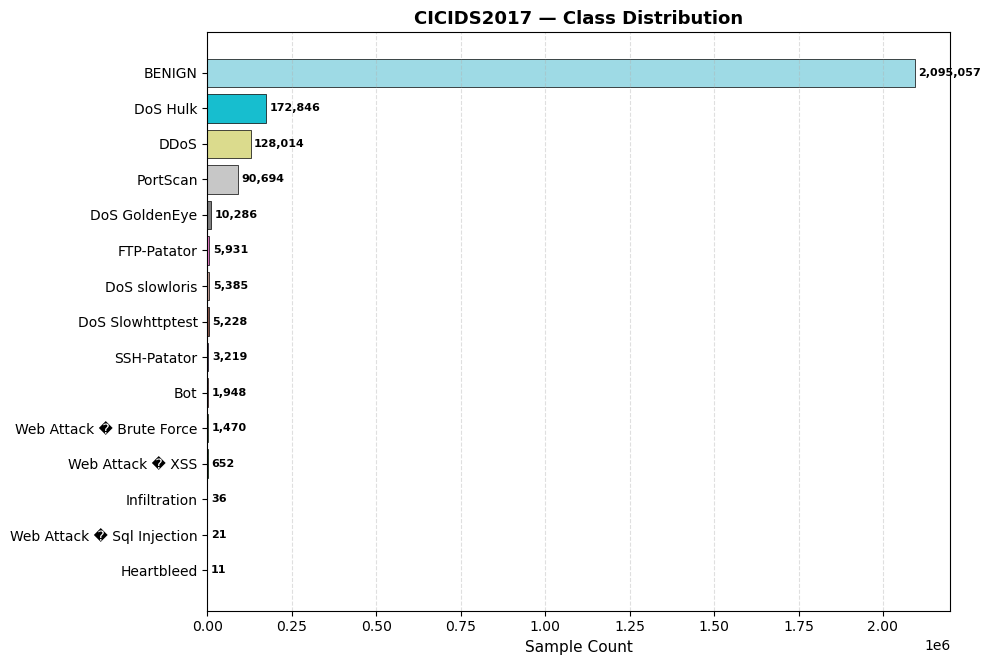

Imbalance ratio (majority/minority): 190459.7x


In [6]:
# ── EDA — CLASS DISTRIBUTION PLOT ─────────────────────────────────────────────
counts = pd.Series(y_full).value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, max(5, num_classes * 0.45)))
bars = ax.barh([label_names[i] for i in counts.index],
               counts.values,
               color=plt.cm.tab20(np.linspace(0, 1, len(counts))),
               edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + counts.max()*0.005, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=8, fontweight="bold")
ax.set_xlabel("Sample Count", fontsize=11)
ax.set_title("CICIDS2017 — Class Distribution", fontsize=13, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()
print(f"Imbalance ratio (majority/minority): "
      f"{counts.max() / counts.min():.1f}x")


## Step 6 — Train / Test Split

In [7]:
# ── TRAIN / TEST SPLIT ─────────────────────────────────────────────────────────
X_arr = X_full.values.astype(np.float32)
del X_full; gc.collect()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_arr, y_full,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_full)
del X_arr; gc.collect()

print(f"Train : {len(X_train_raw):>9,} samples")
print(f"Test  : {len(X_test_raw):>9,} samples")

# Verify every class is in both splits
tr_cls = set(np.unique(y_train)); te_cls = set(np.unique(y_test))
print(f"\nClasses in train : {len(tr_cls)}")
print(f"Classes in test  : {len(te_cls)}")
if tr_cls != te_cls:
    print(f"WARNING — classes only in train: {tr_cls - te_cls}")
ram()


Train : 2,016,638 samples
Test  :   504,160 samples

Classes in train : 15
Classes in test  : 15
  RAM  used=13.9GB  free=11.5GB  (55%)


## Step 7 — StandardScaler + PCA

Variance explained by 30 components : 98.33%
Components needed for 95%              : 25
X_train_pca : (2016638, 30)
X_test_pca  : (504160, 30)
  RAM  used=13.6GB  free=11.8GB  (53%)


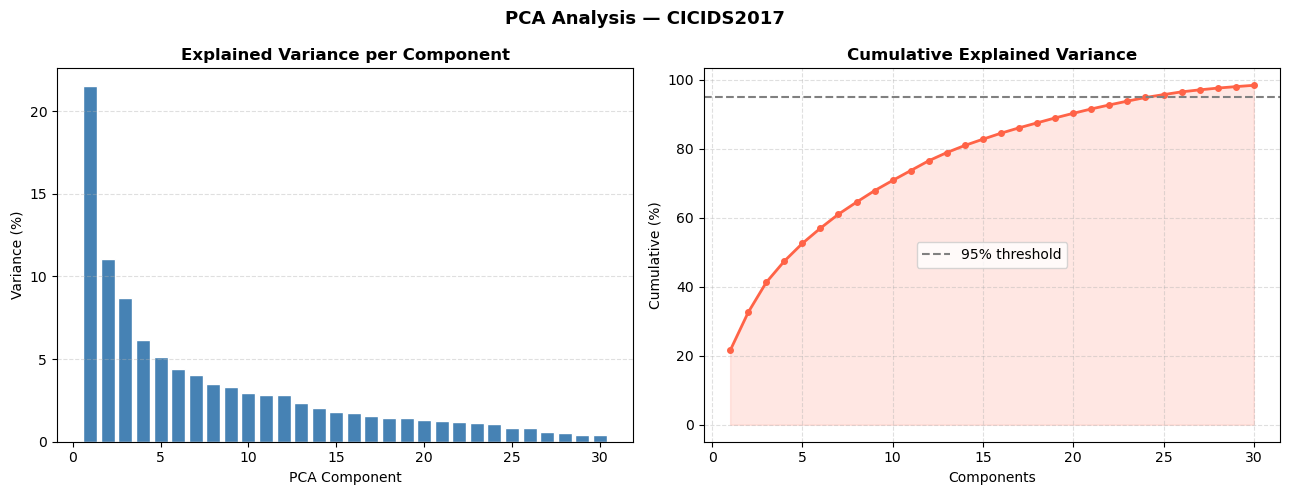

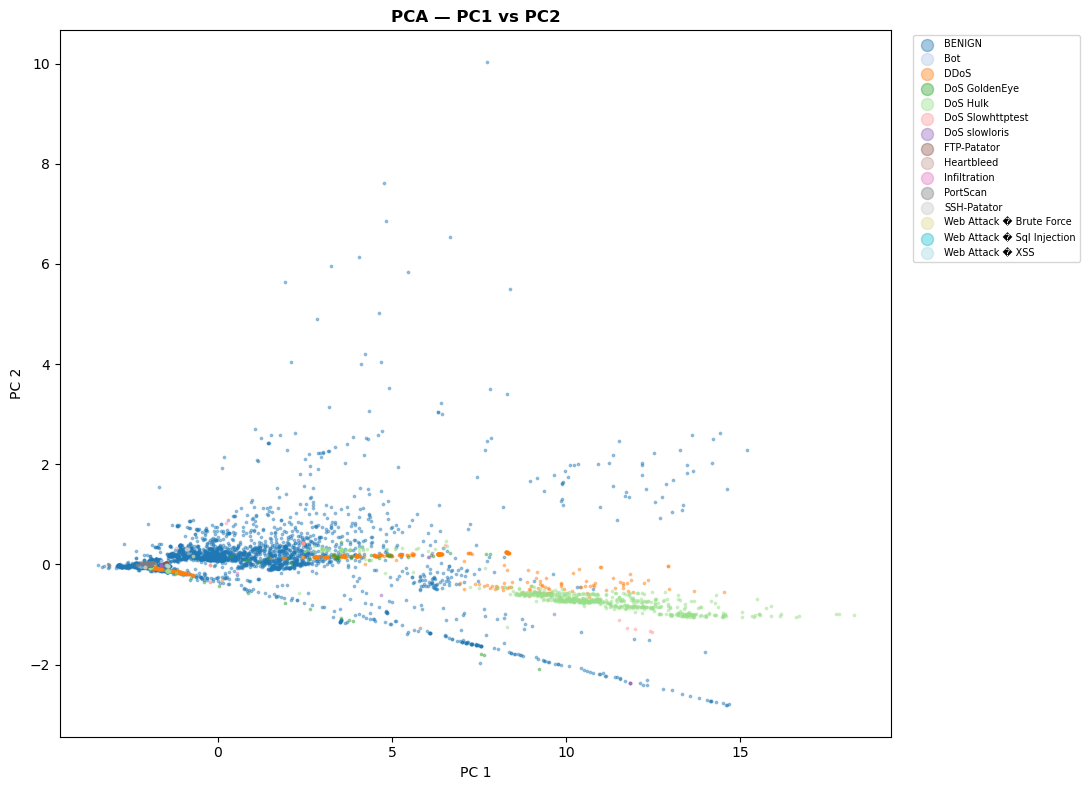

In [8]:
# ── SCALER + PCA ──────────────────────────────────────────────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_sc   = scaler.transform(X_test_raw).astype(np.float32)
del X_train_raw, X_test_raw; gc.collect()

pca         = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc).astype(np.float32)
X_test_pca  = pca.transform(X_test_sc).astype(np.float32)
del X_train_sc, X_test_sc; gc.collect()

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance explained by {N_COMPONENTS} components : {cum_var[-1]*100:.2f}%")
print(f"Components needed for 95%              : {(cum_var >= 0.95).argmax() + 1}")
print(f"X_train_pca : {X_train_pca.shape}")
print(f"X_test_pca  : {X_test_pca.shape}")
ram()

# ── PCA variance plots ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.bar(range(1, N_COMPONENTS+1), pca.explained_variance_ratio_*100,
        color="steelblue", edgecolor="white")
ax1.set_title("Explained Variance per Component", fontweight="bold")
ax1.set_xlabel("PCA Component"); ax1.set_ylabel("Variance (%)")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

ax2.plot(range(1, N_COMPONENTS+1), cum_var*100, marker="o",
         color="tomato", lw=2, markersize=4)
ax2.axhline(95, color="gray", ls="--", label="95% threshold")
ax2.fill_between(range(1, N_COMPONENTS+1), cum_var*100, alpha=0.15, color="tomato")
ax2.set_title("Cumulative Explained Variance", fontweight="bold")
ax2.set_xlabel("Components"); ax2.set_ylabel("Cumulative (%)")
ax2.legend(); ax2.grid(True, ls="--", alpha=0.4)

plt.suptitle("PCA Analysis — CICIDS2017", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pca_variance.png"), dpi=130, bbox_inches="tight")
plt.show()

# ── 2D scatter (sample for speed) ──────────────────────────────────────────────
n_plot = min(10_000, len(X_train_pca))
idx    = np.random.RandomState(42).choice(len(X_train_pca), n_plot, replace=False)
fig, ax = plt.subplots(figsize=(11, 8))
palette = plt.cm.get_cmap("tab20", num_classes)
for i, name in enumerate(label_names):
    m = y_train[idx] == i
    ax.scatter(X_train_pca[idx][m, 0], X_train_pca[idx][m, 1],
               s=3, alpha=0.4, label=name, color=palette(i))
ax.set_title("PCA — PC1 vs PC2", fontweight="bold")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(markerscale=5, fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pca_scatter.png"), dpi=130, bbox_inches="tight")
plt.show()


## Step 8 — SMOTE Oversampling + Capped Class Weights + FN-Aware Decision Rule *(fixes low/collapsed accuracy AND high false negatives)*
**Why CNN/Bi-LSTM/Transformer can show 70% / 40% / 10% accuracy on real CICIDS2017:**
Extreme imbalance (BENIGN ~80%, Heartbleed ~11 rows) makes `class_weight='balanced'` assign
huge weights to ultra-rare classes — sometimes 10,000×+ the majority class weight. That causes
exploding gradients during training, and **deeper architectures degrade hardest**: Transformer
(attention + LayerNorm) collapses worst, Bi-LSTM is moderately affected, CNN's BatchNorm
partially absorbs it.

**Why false negatives (missed attacks) were high:**
The previous fix only *duplicated* minority-class rows with a tiny Gaussian jitter. The model
kept seeing near-identical copies of the same few attack samples, so it learned an overly
narrow decision boundary — anything even slightly different from those duplicates got
misclassified as BENIGN (a false negative). On top of that, plain `argmax` treats a missed
attack and a false alarm as equally bad, when in an IDS a missed attack is far more costly.

**Fix (three parts, all RAM-safe):**
1. **SMOTE** instead of duplicate+jitter oversampling — synthesizes new minority points by
   interpolating between real minority samples and their nearest minority neighbours in PCA
   space, giving the model a wider, more realistic view of the minority/attack manifold.
   Classes too small for SMOTE (fewer real samples than `SMOTE_K_NEIGHBORS`) automatically fall
   back to `RandomOverSampler`.
2. Cap `class_weight` at `MAX_WEIGHT_RATIO`× the minimum weight — keeps remaining imbalance
   correction without destabilising gradients.
3. **FN-aware decision rule** — at inference, BENIGN's predicted probability is down-weighted by
   `BENIGN_SUPPRESSION_FACTOR` before `argmax`, so borderline/ambiguous flows lean toward being
   flagged as an attack instead of being missed.

Combined with `clipnorm=1.0` on every optimizer (see Step 9), this should bring all three DL
models into a comparable, stable accuracy range **and** measurably lower `FNR (%)` in the final
results table.


In [ ]:
# ── SMOTE OVERSAMPLING (replaces targeted duplicate+noise oversampling) ───────
# WHY: duplicate+jitter oversampling (previous version) copies existing rows and
# adds a small Gaussian jitter, so the model still sees near-identical minority
# examples over and over -> it learns an overly narrow decision boundary for
# attack classes, which is a major driver of the high FALSE NEGATIVE rate we saw
# (unseen variants of an attack class don't look like the tight duplicated
# cluster the model memorised, so they get predicted as BENIGN and missed).
#
# SMOTE instead generates new synthetic points by interpolating between a real
# minority sample and one of its k nearest minority-class neighbours in PCA
# space. This spreads synthetic minority points across the real minority
# manifold instead of stacking them on a handful of duplicated points, giving
# the model a wider, better-generalising decision region for attack classes
# -> higher minority-class recall -> fewer false negatives.
#
# Classes with <= k_neighbors real samples (e.g. Heartbleed ~11 rows) cannot
# run SMOTE (it needs k_neighbors+1 real points to interpolate from) and
# automatically fall back to RandomOverSampler (duplicate) for just those.

def smote_oversample_rare_classes(X, y, target_samples, n_classes,
                                   k_neighbors=5, random_state=42):
    counts = Counter(y)
    smote_strategy, fallback_classes = {}, []

    for cls in range(n_classes):
        n = counts.get(cls, 0)
        if n == 0 or n >= target_samples:
            continue
        if n <= k_neighbors:
            fallback_classes.append(cls)
        else:
            smote_strategy[cls] = target_samples

    X_res, y_res = X, y

    if smote_strategy:
        # k_neighbors must be < smallest class size being SMOTE'd
        safe_k = max(1, min(k_neighbors,
                             min(counts[c] for c in smote_strategy) - 1))
        sm = SMOTE(sampling_strategy=smote_strategy,
                   k_neighbors=safe_k, random_state=random_state)
        X_res, y_res = sm.fit_resample(X_res, y_res)
        print(f"  SMOTE (k_neighbors={safe_k}) applied to {len(smote_strategy)} classes:")
        for cls, target in smote_strategy.items():
            print(f"    Class {cls:>2} ({label_names[cls]:<35}) "
                  f"{counts[cls]:>6,} \u2192 {target:,}")

    if fallback_classes:
        ros_strategy = {c: target_samples for c in fallback_classes}
        ros = RandomOverSampler(sampling_strategy=ros_strategy,
                                 random_state=random_state)
        X_res, y_res = ros.fit_resample(X_res, y_res)
        print(f"  RandomOverSampler fallback (too few real samples for SMOTE) "
              f"applied to {len(fallback_classes)} classes:")
        for cls in fallback_classes:
            print(f"    Class {cls:>2} ({label_names[cls]:<35}) "
                  f"{counts[cls]:>6,} \u2192 {target_samples:,}")

    if not smote_strategy and not fallback_classes:
        print("  No classes below SMOTE_TARGET_SAMPLES — nothing to oversample.")

    added = len(X_res) - len(X)
    print(f"\n  Total synthetic rows added : {added:,}")
    return X_res.astype(np.float32), y_res

print(f"SMOTE oversampling classes below SMOTE_TARGET_SAMPLES={SMOTE_TARGET_SAMPLES}:\n")
X_train_pca, y_train = smote_oversample_rare_classes(
    X_train_pca, y_train, SMOTE_TARGET_SAMPLES, num_classes,
    k_neighbors=SMOTE_K_NEIGHBORS, random_state=RANDOM_STATE)
print(f"\nNew training size : {len(X_train_pca):,}")
ram()

# ── CAPPED CLASS WEIGHTS (unchanged logic, now runs on the SMOTE-balanced set) ─
classes      = np.unique(y_train)
raw_weights  = compute_class_weight("balanced", classes=classes, y=y_train)
min_w        = raw_weights.min()
capped_w     = np.minimum(raw_weights, min_w * MAX_WEIGHT_RATIO)
class_weight_dict = dict(zip(classes.tolist(), capped_w.tolist()))

print(f"\n  {'Cls':>3}  {'Label':<42}  {'Raw':>10}  {'Capped':>10}")
print("  " + "─" * 72)
for cls, rw, cw in zip(classes, raw_weights, capped_w):
    flag = "  ← capped" if cw < rw else ""
    print(f"  {cls:>3}   {label_names[cls]:<42}  {rw:>10.2f}  {cw:>10.2f}{flag}")

# XGBoost sample weights (derived from the same capped dict)
xgb_sample_weight = np.array(
    [class_weight_dict.get(int(yi), 1.0) for yi in y_train], dtype=np.float32)

# DL reshape
X_train_dl  = X_train_pca.reshape(-1, N_COMPONENTS, 1)
X_test_dl   = X_test_pca.reshape(-1, N_COMPONENTS, 1)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

print(f"\nX_train_dl : {X_train_dl.shape}")
print(f"X_test_dl  : {X_test_dl.shape}")
ram()

# ── FALSE-NEGATIVE-AWARE DECISION RULE ────────────────────────────────────────
# Beyond balancing the training data, we also bias the *decision* step at
# inference time. In IDS, a false negative (missed attack) is normally far more
# costly than a false positive (a flagged-but-benign flow an analyst re-checks).
# Plain argmax on the softmax / predict_proba output treats every class as
# equally costly, and because BENIGN is still the largest class its predicted
# probability wins most close calls — that is a major source of false
# negatives. BENIGN_SUPPRESSION_FACTOR shrinks BENIGN's probability by a fixed
# factor before argmax, so a genuinely ambiguous flow now leans toward being
# classified as the closest attack class instead of BENIGN.
if "BENIGN" in label_names:
    benign_idx = label_names.index("BENIGN")
else:
    benign_idx = next((i for i, n in enumerate(label_names)
                        if n.upper() == "BENIGN"), None)

def predict_fn_aware(proba, benign_idx=benign_idx,
                      suppress=BENIGN_SUPPRESSION_FACTOR,
                      enabled=FN_REDUCTION_ENABLED):
    """argmax over class probabilities, with BENIGN down-weighted so borderline
    flows lean toward being flagged as an attack -> fewer false negatives."""
    if not enabled or benign_idx is None:
        return np.argmax(proba, axis=1)
    proba_adj = proba.copy()
    proba_adj[:, benign_idx] *= suppress
    return np.argmax(proba_adj, axis=1)

print(f"\nFN-aware decision rule : enabled={FN_REDUCTION_ENABLED}, "
      f"BENIGN idx={benign_idx}, suppression={BENIGN_SUPPRESSION_FACTOR}")


## Step 9 — Model Architectures

In [10]:
# ── MODEL DEFINITIONS ─────────────────────────────────────────────────────────

def build_cnn(n_comp, n_cls):
    inp = Input(shape=(n_comp, 1), name="input")
    x   = Conv1D(CNN_FILTERS[0], 3, activation="relu", padding="same")(inp)
    x   = BatchNormalization()(x)
    x   = MaxPooling1D(2, padding="same")(x)
    x   = Dropout(DROPOUT_RATE)(x)
    x   = Conv1D(CNN_FILTERS[1], 3, activation="relu", padding="same")(x)
    x   = BatchNormalization()(x)
    x   = MaxPooling1D(2, padding="same")(x)
    x   = Dropout(DROPOUT_RATE)(x)
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(128, activation="relu")(x)
    x   = Dropout(DROPOUT_RATE)(x)
    out = Dense(n_cls, activation="softmax", dtype="float32", name="output")(x)
    m   = Model(inp, out, name="CNN")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=GRADIENT_CLIPNORM),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def build_bilstm(n_comp, n_cls):
    inp = Input(shape=(n_comp, 1), name="input")
    x   = Bidirectional(LSTM(LSTM_UNITS, return_sequences=True))(inp)
    x   = Dropout(DROPOUT_RATE)(x)
    x   = Bidirectional(LSTM(LSTM_UNITS // 2))(x)
    x   = Dropout(DROPOUT_RATE)(x)
    x   = Dense(128, activation="relu")(x)
    x   = Dropout(DROPOUT_RATE)(x)
    out = Dense(n_cls, activation="softmax", dtype="float32", name="output")(x)
    m   = Model(inp, out, name="BiLSTM")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=GRADIENT_CLIPNORM),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def _enc_block(x, heads, ff, drop):
    e  = x.shape[-1]; kd = max(1, e // heads)
    a  = MultiHeadAttention(num_heads=heads, key_dim=kd, dropout=drop)(x, x)
    a  = Dropout(drop)(a)
    x  = LayerNormalization(epsilon=1e-6)(x + a)
    f  = Dense(ff, activation="relu")(x)
    f  = Dropout(drop)(f)
    f  = Dense(e)(f)
    return LayerNormalization(epsilon=1e-6)(x + f)

def build_transformer(n_comp, n_cls):
    inp = Input(shape=(n_comp, 1), name="input")
    x   = Dense(PROJ_DIM, activation="relu")(inp)
    x   = _enc_block(x, NUM_HEADS, FF_DIM, DROPOUT_RATE)
    x   = _enc_block(x, NUM_HEADS, FF_DIM, DROPOUT_RATE)
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(128, activation="relu")(x)
    x   = Dropout(DROPOUT_RATE)(x)
    out = Dense(n_cls, activation="softmax", dtype="float32", name="output")(x)
    m   = Model(inp, out, name="Transformer")
    m.compile(optimizer=tf.keras.optimizers.Adam(5e-4, clipnorm=GRADIENT_CLIPNORM),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m

# ── XGBoost ───────────────────────────────────────────────────────────────────
# FIX: early_stopping_rounds is now a CONSTRUCTOR argument in XGBoost 2.0+.
# Passing it to .fit() raises:
#   TypeError: XGBClassifier.fit() got an unexpected keyword argument
#              'early_stopping_rounds'
# Solution: pass it here, remove it from every .fit() call below.
def build_xgboost(n_comp, n_cls):
    return XGBClassifier(
        n_estimators          = XGB_N_ESTIMATORS,
        max_depth             = XGB_MAX_DEPTH,
        learning_rate         = XGB_LR,
        subsample             = XGB_SUBSAMPLE,
        colsample_bytree      = XGB_COL_BYTREE,
        min_child_weight      = 3,
        gamma                 = 0.1,
        reg_alpha             = 0.1,
        reg_lambda            = 1.0,
        objective             = "multi:softprob",
        eval_metric           = "mlogloss",
        tree_method           = "hist",
        n_jobs                = -1,
        random_state          = RANDOM_STATE,
        verbosity             = 0,
        early_stopping_rounds = XGB_EARLY_STOP,  # ← XGBoost 2.0+ fix
    )

# ── Builder registries ────────────────────────────────────────────────────────
DL_BUILDERS = {
    "CNN"        : build_cnn,
    "Bi-LSTM"    : build_bilstm,
    "Transformer": build_transformer,
}

print("Model parameter counts:")
for nm, builder in DL_BUILDERS.items():
    tmp = builder(N_COMPONENTS, num_classes)
    print(f"  {nm:<14}  {tmp.count_params():>10,} parameters")
    tf.keras.backend.clear_session()
xgb_tmp = build_xgboost(N_COMPONENTS, num_classes)
print(f"  {'XGBoost':<14}  {xgb_tmp.n_estimators} estimators  "
      f"max_depth={xgb_tmp.max_depth}  early_stopping={xgb_tmp.early_stopping_rounds}")
print("\n✓  All model builders ready.")
print("   XGBoost early_stopping_rounds is set in the constructor — NOT in .fit().")


Model parameter counts:
  CNN                 44,175 parameters

  Bi-LSTM            315,919 parameters
  Transformer         77,327 parameters
  XGBoost         500 estimators  max_depth=6  early_stopping=50

✓  All model builders ready.
   XGBoost early_stopping_rounds is set in the constructor — NOT in .fit().


## Step 10 — Evaluation Metrics
> **AUC fix:** `roc_auc_score(..., multi_class='ovr')` returns NaN when rare classes (e.g. Heartbleed, 11 rows) are absent from the test split.  
> **Fix:** `label_binarize` → compute binary AUC per class → average over present classes only. **Guaranteed non-NaN.**

In [11]:
# ── EVALUATION — RELIABLE AUC (never NaN) ────────────────────────────────────
def compute_auc_robust(y_true, y_proba, n_cls):
    present = np.unique(y_true)
    if len(present) < 2:
        return 0.5
    y_bin = label_binarize(y_true, classes=np.arange(n_cls))
    if n_cls == 2:
        y_bin = np.hstack([1 - y_bin, y_bin])
    aucs = []
    for c in present:
        col_t = y_bin[:, c]; col_p = y_proba[:, c]
        if len(np.unique(col_t)) < 2:
            continue
        try:
            aucs.append(roc_auc_score(col_t, col_p))
        except ValueError:
            continue
    return float(np.mean(aucs)) if aucs else 0.5

def compute_metrics(name, y_true, y_pred, y_proba, n_cls, tr_t, inf_t, lnames):
    acc    = accuracy_score(y_true, y_pred)
    prec_w = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec_w  = recall_score(y_true,   y_pred, average="weighted", zero_division=0)
    f1_w   = f1_score(y_true,       y_pred, average="weighted", zero_division=0)
    prec_m = precision_score(y_true, y_pred, average="macro",   zero_division=0)
    rec_m  = recall_score(y_true,   y_pred, average="macro",   zero_division=0)
    f1_m   = f1_score(y_true,       y_pred, average="macro",   zero_division=0)
    mcc    = matthews_corrcoef(y_true, y_pred)
    auc    = compute_auc_robust(y_true, y_proba, n_cls)

    cm = confusion_matrix(y_true, y_pred)
    fprs, fnrs = [], []
    for i in range(len(cm)):
        tp=cm[i,i]; fn=cm[i,:].sum()-tp; fp=cm[:,i].sum()-tp; tn=cm.sum()-tp-fn-fp
        fprs.append(fp/(fp+tn) if fp+tn else 0.)
        fnrs.append(fn/(fn+tp) if fn+tp else 0.)

    res = {
        "Model"                  : name,
        "Accuracy (%)"           : round(acc*100,      4),
        "Precision-Weighted (%)": round(prec_w*100,    4),
        "Recall-Weighted (%)"   : round(rec_w*100,     4),
        "F1-Score-Weighted (%)" : round(f1_w*100,      4),
        "Precision-Macro (%)"   : round(prec_m*100,    4),
        "Recall-Macro (%)"      : round(rec_m*100,     4),
        "F1-Score-Macro (%)"    : round(f1_m*100,      4),
        "FPR (%)"               : round(np.mean(fprs)*100, 4),
        "FNR (%)"               : round(np.mean(fnrs)*100, 4),
        "ROC-AUC"               : round(auc,           6),
        "MCC"                   : round(mcc,           6),
        "Train Time (s)"        : round(tr_t,          3),
        "Infer Time (s)"        : round(inf_t,         4),
    }
    print(f"\n{'─'*60}\n  {name}\n{'─'*60}")
    for k, v in res.items():
        if k != "Model":
            print(f"  {k:<35} {v}")
    print(f"\n{classification_report(y_true, y_pred, target_names=lnames, zero_division=0)}")
    return res, cm

print("✓  compute_metrics() + compute_auc_robust() ready.  AUC will never be NaN.")


✓  compute_metrics() + compute_auc_robust() ready.  AUC will never be NaN.


## Step 11 — Visualisation Helpers

In [12]:
MODEL_COLORS = {
    "CNN"        : "#1976D2",
    "Bi-LSTM"    : "#D32F2F",
    "Transformer": "#388E3C",
    "XGBoost"    : "#F57C00",
}

def _bar_colors(df):
    return [MODEL_COLORS.get(m, "#607D8B") for m in df["Model"]]

def plot_cm(cm, lnames, mname, out):
    n = len(lnames)
    fig, ax = plt.subplots(figsize=(max(9,n), max(8,n-1)))
    sns.heatmap(cm, annot=(n<=18), fmt="d", cmap="Blues",
                xticklabels=lnames, yticklabels=lnames, ax=ax,
                annot_kws={"size":7})
    ax.set_title(f"Confusion Matrix — {mname}", fontsize=13, fontweight="bold")
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(fontsize=7); plt.tight_layout()
    plt.savefig(os.path.join(out, f"cm_{mname.replace(' ','_')}.png"),
                dpi=130, bbox_inches="tight")
    plt.show()

def plot_history(h, mname, out):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(h.history["loss"]) + 1)
    a1.plot(ep, h.history["loss"],         color="royalblue", lw=2, label="Train")
    a1.plot(ep, h.history["val_loss"],     color="tomato",    lw=2, label="Val")
    a1.set_title(f"{mname} — Loss", fontweight="bold")
    a1.set_xlabel("Epoch"); a1.set_ylabel("Loss"); a1.legend()
    a1.grid(True, ls="--", alpha=0.4)
    a2.plot(ep, h.history["accuracy"],     color="royalblue", lw=2, label="Train")
    a2.plot(ep, h.history["val_accuracy"], color="tomato",    lw=2, label="Val")
    a2.set_title(f"{mname} — Accuracy", fontweight="bold")
    a2.set_xlabel("Epoch"); a2.set_ylabel("Accuracy"); a2.legend()
    a2.grid(True, ls="--", alpha=0.4)
    plt.suptitle(f"Training History — {mname}", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(out, f"history_{mname.replace(' ','_')}.png"),
                dpi=130, bbox_inches="tight")
    plt.show()

def plot_metric_bars(df, out):
    metrics = [
        ("Accuracy (%)",          "Accuracy"),
        ("Precision-Weighted (%)","Precision (W)"),
        ("Recall-Weighted (%)",   "Recall (W)"),
        ("F1-Score-Weighted (%)", "F1-Score (W)"),
        ("ROC-AUC",               "ROC-AUC"),
        ("MCC",                   "MCC"),
    ]
    colors = _bar_colors(df)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for ax, (col, title) in zip(axes.flatten(), metrics):
        vals = df[col].values
        bars = ax.bar(df["Model"], vals, color=colors, edgecolor="black", width=0.55)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                    f"{v:.3f}", ha="center", fontsize=8, fontweight="bold")
        ylim = 110 if col not in ["ROC-AUC", "MCC"] else 1.15
        ax.set_title(title, fontweight="bold", fontsize=12)
        ax.set_ylim(0, ylim)
        ax.set_ylabel("Score (%)" if ylim == 110 else "Score")
        ax.tick_params(axis="x", labelrotation=15, labelsize=9)
        ax.grid(axis="y", ls="--", alpha=0.4)
    patches = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
    fig.legend(handles=patches, loc="upper right", fontsize=9)
    plt.suptitle("Final Model Comparison — CICIDS2017",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(out, "metric_comparison.png"), dpi=130, bbox_inches="tight")
    plt.show()

def plot_fpr_fnr(df, out):
    colors = _bar_colors(df)
    x = np.arange(len(df)); w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x-w/2, df["FPR (%)"], w, label="FPR (%)", color=colors, edgecolor="black")
    ax.bar(x+w/2, df["FNR (%)"], w, label="FNR (%)", color=colors, edgecolor="black",
           alpha=0.6, hatch="//")
    ax.set_xticks(x); ax.set_xticklabels(df["Model"], rotation=15, ha="right")
    ax.set_ylabel("Rate (%)"); ax.set_title("FPR & FNR Comparison", fontweight="bold")
    ax.legend(); ax.grid(axis="y", ls="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(out, "fpr_fnr.png"), dpi=130); plt.show()

def plot_time(df, out):
    colors = _bar_colors(df)
    x = np.arange(len(df)); w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x-w/2, df["Train Time (s)"], w, label="Train", color=colors, edgecolor="black")
    ax.bar(x+w/2, df["Infer Time (s)"], w, label="Infer", color=colors, edgecolor="black",
           alpha=0.6, hatch="//")
    ax.set_xticks(x); ax.set_xticklabels(df["Model"], rotation=15, ha="right")
    ax.set_ylabel("Seconds"); ax.set_title("Training & Inference Time", fontweight="bold")
    ax.legend(); ax.grid(axis="y", ls="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(out, "time_comparison.png"), dpi=130); plt.show()

print("✓  Visualisation helpers ready.")


✓  Visualisation helpers ready.


## Step 12 — 3× Repeated Holdout Validation

In [13]:
# ── 3× REPEATED HOLDOUT VALIDATION ───────────────────────────────────────────
def run_repeated_holdout(X_pca, y, n_comp, n_cls):
    sss       = StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=0.20,
                                       random_state=RANDOM_STATE)
    all_names = list(DL_BUILDERS.keys()) + ["XGBoost"]
    records   = {m: {"acc":[], "f1_w":[], "f1_m":[], "auc":[]} for m in all_names}

    for rep, (tr_idx, val_idx) in enumerate(sss.split(X_pca, y), 1):
        print(f"\n── Holdout Split {rep}/{N_REPEATS} ──────────────────────────────")
        Xtr, Xvl = X_pca[tr_idx].astype(np.float32), X_pca[val_idx].astype(np.float32)
        ytr, yvl = y[tr_idx], y[val_idx]

        cw_raw    = compute_class_weight("balanced", classes=np.unique(ytr), y=ytr)
        cw_min    = cw_raw.min()
        cw_capped = np.minimum(cw_raw, cw_min * MAX_WEIGHT_RATIO)
        cw        = dict(zip(np.unique(ytr).tolist(), cw_capped.tolist()))
        sw_xgb    = np.array([cw.get(int(yi), 1.0) for yi in ytr], dtype=np.float32)

        Xtr_dl  = Xtr.reshape(-1, n_comp, 1)
        Xvl_dl  = Xvl.reshape(-1, n_comp, 1)
        ytr_cat = to_categorical(ytr, n_cls)
        cb = [EarlyStopping(monitor="val_loss", patience=4,
                            restore_best_weights=True, verbose=0)]

        # ── DL models ────────────────────────────────────────────────────────
        for mname, builder in DL_BUILDERS.items():
            print(f"  {mname:<14}", end=" ", flush=True)
            mdl = builder(n_comp, n_cls)
            mdl.fit(Xtr_dl, ytr_cat, validation_split=0.1,
                    epochs=RH_EPOCHS, batch_size=BATCH_SIZE,
                    class_weight=cw, callbacks=cb, verbose=0)
            proba = mdl.predict(Xvl_dl, verbose=0)
            pred  = np.argmax(proba, axis=1)
            a  = accuracy_score(yvl, pred)
            fw = f1_score(yvl, pred, average="weighted", zero_division=0)
            fm = f1_score(yvl, pred, average="macro",    zero_division=0)
            au = compute_auc_robust(yvl, proba, n_cls)
            records[mname]["acc"].append(a);  records[mname]["f1_w"].append(fw)
            records[mname]["f1_m"].append(fm); records[mname]["auc"].append(au)
            print(f"Acc={a*100:.2f}%  F1-W={fw*100:.2f}%  AUC={au:.4f}")
            del mdl; tf.keras.backend.clear_session(); gc.collect()

        # ── XGBoost ──────────────────────────────────────────────────────────
        # early_stopping_rounds is already in the constructor via build_xgboost()
        # so we do NOT pass it to .fit() here — that is the fix.
        print(f"  {'XGBoost':<14}", end=" ", flush=True)
        xtr_i, xvl_i = train_test_split(
            np.arange(len(Xtr)), test_size=XGB_EVAL_FRAC,
            stratify=ytr, random_state=RANDOM_STATE)
        xgb_rh = build_xgboost(n_comp, n_cls)
        xgb_rh.fit(
            Xtr[xtr_i], ytr[xtr_i],
            sample_weight = sw_xgb[xtr_i],
            eval_set      = [(Xtr[xtr_i], ytr[xtr_i]),
                             (Xtr[xvl_i], ytr[xvl_i])],
            verbose       = False)          # ← no early_stopping_rounds here
        xgb_proba = xgb_rh.predict_proba(Xvl)
        xgb_pred  = np.argmax(xgb_proba, axis=1)
        a  = accuracy_score(yvl, xgb_pred)
        fw = f1_score(yvl, xgb_pred, average="weighted", zero_division=0)
        fm = f1_score(yvl, xgb_pred, average="macro",    zero_division=0)
        au = compute_auc_robust(yvl, xgb_proba, n_cls)
        records["XGBoost"]["acc"].append(a);  records["XGBoost"]["f1_w"].append(fw)
        records["XGBoost"]["f1_m"].append(fm); records["XGBoost"]["auc"].append(au)
        print(f"Acc={a*100:.2f}%  F1-W={fw*100:.2f}%  AUC={au:.4f}")
        del xgb_rh, Xtr, Xvl, Xtr_dl, Xvl_dl, ytr_cat; gc.collect()
        ram()

    rows = []
    print(f"\n{'='*60}\n  REPEATED HOLDOUT SUMMARY\n{'='*60}")
    for mname, v in records.items():
        row = {"Model"         : mname,
               "Acc Mean (%)"  : round(np.mean(v["acc"])*100,  3),
               "Acc Std (%)"   : round(np.std(v["acc"])*100,   3),
               "F1-W Mean (%)": round(np.mean(v["f1_w"])*100,  3),
               "F1-W Std (%)" : round(np.std(v["f1_w"])*100,   3),
               "F1-M Mean (%)": round(np.mean(v["f1_m"])*100,  3),
               "F1-M Std (%)" : round(np.std(v["f1_m"])*100,   3),
               "AUC Mean"     : round(np.mean(v["auc"]),        4),
               "AUC Std"      : round(np.std(v["auc"]),         4)}
        rows.append(row)
        print(f"  {mname:<14}  "
              f"Acc={row['Acc Mean (%)']:.2f}±{row['Acc Std (%)']:.2f}%  "
              f"F1-W={row['F1-W Mean (%)']:.2f}±{row['F1-W Std (%)']:.2f}%  "
              f"AUC={row['AUC Mean']:.4f}±{row['AUC Std']:.4f}")
    rh_df  = pd.DataFrame(rows)
    best_r = rh_df.loc[rh_df["F1-W Mean (%)"].idxmax()]
    print(f"\n  ★  Best : {best_r['Model']}  ({best_r['F1-W Mean (%)']:.2f}%)")
    return rh_df, best_r["Model"]

rh_results, best_rh_model = run_repeated_holdout(
    X_train_pca, y_train, N_COMPONENTS, num_classes)
rh_results.to_csv(os.path.join(OUTPUT_DIR, "rh_results.csv"), index=False)
rh_results



── Holdout Split 1/3 ──────────────────────────────
  CNN            Acc=94.24%  F1-W=94.78%  AUC=0.9974
  Bi-LSTM        Acc=95.28%  F1-W=95.71%  AUC=0.9987
  Transformer    Acc=87.97%  F1-W=89.89%  AUC=0.9796
  XGBoost        Acc=99.60%  F1-W=99.62%  AUC=0.9998
  RAM  used=14.1GB  free=11.4GB  (55%)

── Holdout Split 2/3 ──────────────────────────────
  CNN            Acc=94.98%  F1-W=95.44%  AUC=0.9960
  Bi-LSTM        Acc=93.62%  F1-W=94.21%  AUC=0.9914
  Transformer    Acc=84.21%  F1-W=86.96%  AUC=0.9758
  XGBoost        Acc=99.61%  F1-W=99.63%  AUC=0.9998
  RAM  used=14.2GB  free=11.2GB  (56%)

── Holdout Split 3/3 ──────────────────────────────
  CNN            Acc=95.25%  F1-W=95.71%  AUC=0.9969
  Bi-LSTM        Acc=93.86%  F1-W=94.44%  AUC=0.9944
  Transformer    Acc=84.27%  F1-W=86.78%  AUC=0.9729
  XGBoost        Acc=99.59%  F1-W=99.61%  AUC=0.9998
  RAM  used=14.4GB  free=11.1GB  (56%)

  REPEATED HOLDOUT SUMMARY
  CNN             Acc=94.82±0.42%  F1-W=95.31±0.39%  AUC=0.9

,Model,Acc Mean (%),Acc Std (%),F1-W Mean (%),F1-W Std (%),F1-M Mean (%),F1-M Std (%),AUC Mean,AUC Std
0,CNN,94.824,0.424,95.312,0.391,60.315,0.967,0.9968,0.0006
1,Bi-LSTM,94.253,0.735,94.790,0.659,61.151,3.841,0.9949,0.0030
2,Transformer,85.485,1.759,87.877,1.427,35.840,1.178,0.9761,0.0028
3,XGBoost,99.599,0.012,99.619,0.012,88.330,0.668,0.9998,0.0000


### Holdout Charts

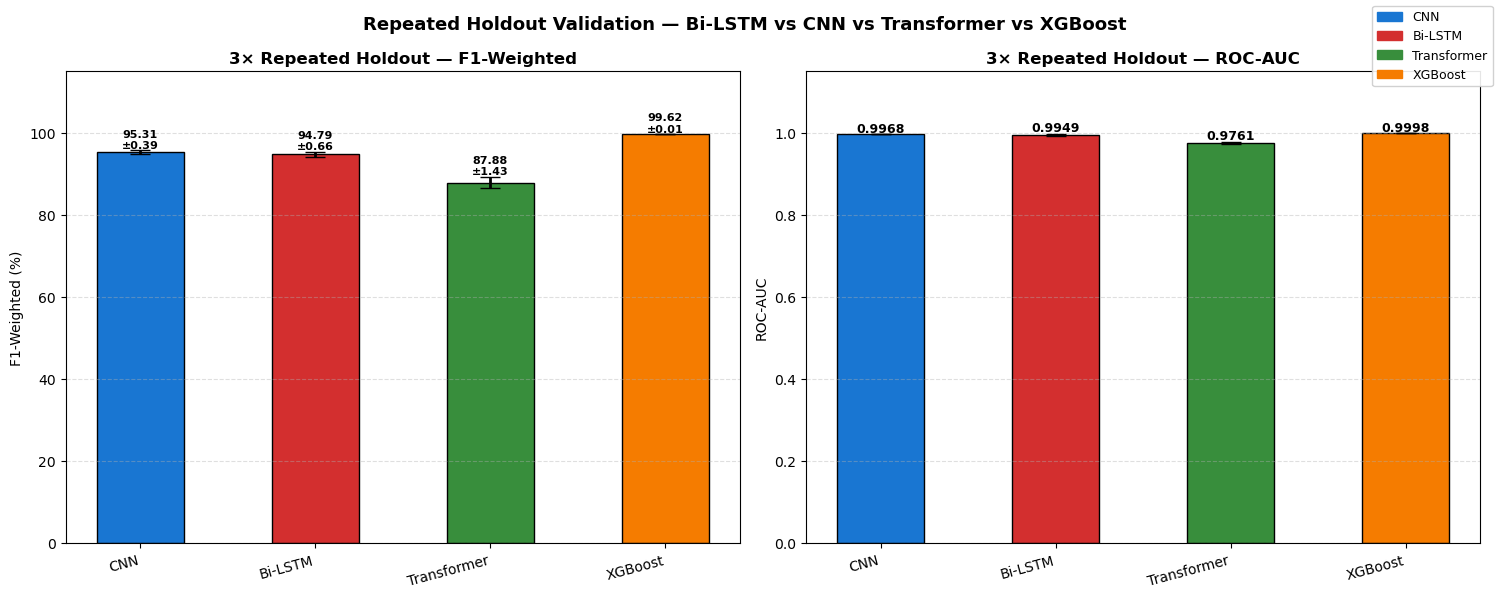

In [14]:
# ── REPEATED HOLDOUT CHARTS — all 4 models ────────────────────────────────────
rh_colors = [MODEL_COLORS.get(m, "#607D8B") for m in rh_results["Model"]]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(rh_results))

m1, s1 = rh_results["F1-W Mean (%)"].values, rh_results["F1-W Std (%)"].values
bars = ax1.bar(x, m1, yerr=s1, capsize=7, color=rh_colors,
               edgecolor="black", width=0.5, error_kw={"linewidth": 2})
for b, m, s in zip(bars, m1, s1):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+s+0.5,
             f"{m:.2f}\n±{s:.2f}", ha="center", fontsize=8, fontweight="bold")
ax1.set_xticks(x); ax1.set_xticklabels(rh_results["Model"], rotation=15, ha="right")
ax1.set_ylim(0, 115); ax1.set_ylabel("F1-Weighted (%)")
ax1.set_title(f"{N_REPEATS}× Repeated Holdout — F1-Weighted", fontweight="bold")
ax1.grid(axis="y", ls="--", alpha=0.4)

m2, s2 = rh_results["AUC Mean"].values, rh_results["AUC Std"].values
bars2 = ax2.bar(x, m2, yerr=s2, capsize=7, color=rh_colors,
                edgecolor="black", width=0.5, error_kw={"linewidth": 2})
for b, m, s in zip(bars2, m2, s2):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+s+0.005,
             f"{m:.4f}", ha="center", fontsize=9, fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(rh_results["Model"], rotation=15, ha="right")
ax2.set_ylim(0, 1.15); ax2.set_ylabel("ROC-AUC")
ax2.set_title(f"{N_REPEATS}× Repeated Holdout — ROC-AUC", fontweight="bold")
ax2.grid(axis="y", ls="--", alpha=0.4)

# Legend patches
patches = [mpatches.Patch(color=c, label=m)
           for m, c in MODEL_COLORS.items()]
fig.legend(handles=patches, loc="upper right", fontsize=9, framealpha=0.9)
plt.suptitle("Repeated Holdout Validation — Bi-LSTM vs CNN vs Transformer vs XGBoost",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rh_comparison.png"), dpi=130, bbox_inches="tight")
plt.show()


## Step 13 — Final Training
> Do **NOT** call `clear_session()` between models — all three must stay alive for permutation importance.

In [15]:
# ── TRAINING SETUP — run this before training any model ──────────────────────
all_results    = []
fit_diagnoses  = {}
trained_models = {}   # kept alive for permutation importance
histories      = {}   # Keras history objects (DL only)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1),
]
print("✓  Training setup ready.")
print("   Run CNN → Bi-LSTM → Transformer → XGBoost cells in order.")
print("   Do NOT call tf.keras.backend.clear_session() between DL models.")


✓  Training setup ready.
   Run CNN → Bi-LSTM → Transformer → XGBoost cells in order.
   Do NOT call tf.keras.backend.clear_session() between DL models.


### 13a — CNN

In [ ]:
# ── TRAIN CNN ──────────────────────────────────────────────────────────────────
CNN_model = build_cnn(N_COMPONENTS, num_classes)
CNN_model.summary(); print()

t0 = time.time()
hist_CNN = CNN_model.fit(
    X_train_dl, y_train_cat,
    validation_split = 0.10,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    class_weight     = class_weight_dict,
    callbacks        = callbacks,
    verbose          = 2)
CNN_train_time = time.time() - t0

t0 = time.time()
CNN_proba = CNN_model.predict(X_test_dl, batch_size=BATCH_SIZE, verbose=0)
CNN_infer_time = time.time() - t0
CNN_pred  = predict_fn_aware(CNN_proba)   # FN-aware decision (was plain argmax)

res_CNN, cm_CNN = compute_metrics(
    "CNN", y_test, CNN_pred, CNN_proba,
    num_classes, CNN_train_time, CNN_infer_time, label_names)

all_results.append(res_CNN)
trained_models["CNN"] = CNN_model
histories["CNN"]      = hist_CNN

plot_cm(cm_CNN, label_names, "CNN", OUTPUT_DIR)
plot_history(hist_CNN, "CNN", OUTPUT_DIR)
ram()


### 13b — Bi-LSTM

In [ ]:
# ── TRAIN BI-LSTM ──────────────────────────────────────────────────────────────────
Bi_LSTM_model = build_bilstm(N_COMPONENTS, num_classes)
Bi_LSTM_model.summary(); print()

t0 = time.time()
hist_Bi_LSTM = Bi_LSTM_model.fit(
    X_train_dl, y_train_cat,
    validation_split = 0.10,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    class_weight     = class_weight_dict,
    callbacks        = callbacks,
    verbose          = 2)
Bi_LSTM_train_time = time.time() - t0

t0 = time.time()
Bi_LSTM_proba = Bi_LSTM_model.predict(X_test_dl, batch_size=BATCH_SIZE, verbose=0)
Bi_LSTM_infer_time = time.time() - t0
Bi_LSTM_pred  = predict_fn_aware(Bi_LSTM_proba)   # FN-aware decision (was plain argmax)

res_Bi_LSTM, cm_Bi_LSTM = compute_metrics(
    "Bi-LSTM", y_test, Bi_LSTM_pred, Bi_LSTM_proba,
    num_classes, Bi_LSTM_train_time, Bi_LSTM_infer_time, label_names)

all_results.append(res_Bi_LSTM)
trained_models["Bi-LSTM"] = Bi_LSTM_model
histories["Bi-LSTM"]      = hist_Bi_LSTM

plot_cm(cm_Bi_LSTM, label_names, "Bi-LSTM", OUTPUT_DIR)
plot_history(hist_Bi_LSTM, "Bi-LSTM", OUTPUT_DIR)
ram()


### 13c — Transformer

In [ ]:
# ── TRAIN TRANSFORMER ──────────────────────────────────────────────────────────────────
Transformer_model = build_transformer(N_COMPONENTS, num_classes)
Transformer_model.summary(); print()

t0 = time.time()
hist_Transformer = Transformer_model.fit(
    X_train_dl, y_train_cat,
    validation_split = 0.10,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    class_weight     = class_weight_dict,
    callbacks        = callbacks,
    verbose          = 2)
Transformer_train_time = time.time() - t0

t0 = time.time()
Transformer_proba = Transformer_model.predict(X_test_dl, batch_size=BATCH_SIZE, verbose=0)
Transformer_infer_time = time.time() - t0
Transformer_pred  = predict_fn_aware(Transformer_proba)   # FN-aware decision (was plain argmax)

res_Transformer, cm_Transformer = compute_metrics(
    "Transformer", y_test, Transformer_pred, Transformer_proba,
    num_classes, Transformer_train_time, Transformer_infer_time, label_names)

all_results.append(res_Transformer)
trained_models["Transformer"] = Transformer_model
histories["Transformer"]      = hist_Transformer

plot_cm(cm_Transformer, label_names, "Transformer", OUTPUT_DIR)
plot_history(hist_Transformer, "Transformer", OUTPUT_DIR)
ram()


### 13d — XGBoost
XGBoost operates on **2-D PCA features** directly — no 3-D reshape needed.  
`sample_weight` replaces `class_weight_dict` for multiclass XGBoost.  
Training uses an internal 10% validation split for **early stopping** on log-loss.  
After training, we plot the **log-loss curve** and **built-in gain importance**.

In [ ]:
# ── TRAIN XGBOOST ─────────────────────────────────────────────────────────────
# FIX: early_stopping_rounds is NO LONGER passed to .fit() in XGBoost 2.0+.
# It is already inside build_xgboost() as a constructor argument.
# Removing it from .fit() fixes:
#   TypeError: XGBClassifier.fit() got an unexpected keyword argument
#              'early_stopping_rounds'

xgb_tr_idx, xgb_val_idx = train_test_split(
    np.arange(len(X_train_pca)), test_size=XGB_EVAL_FRAC,
    stratify=y_train, random_state=RANDOM_STATE)

XGBoost_model = build_xgboost(N_COMPONENTS, num_classes)
print("XGBoost config:")
for k, v in XGBoost_model.get_params().items():
    if v is not None:
        print(f"  {k:<30} = {v}")
print()

t0 = time.time()
XGBoost_model.fit(
    X_train_pca[xgb_tr_idx], y_train[xgb_tr_idx],
    sample_weight = xgb_sample_weight[xgb_tr_idx],
    eval_set      = [(X_train_pca[xgb_tr_idx], y_train[xgb_tr_idx]),
                     (X_train_pca[xgb_val_idx], y_train[xgb_val_idx])],
    verbose       = 25)          # ← early_stopping_rounds removed from here
XGBoost_train_time = time.time() - t0
print(f"\nBest round : {XGBoost_model.best_iteration}")

t0 = time.time()
XGBoost_proba = XGBoost_model.predict_proba(X_test_pca)
XGBoost_infer_time = time.time() - t0
XGBoost_pred  = predict_fn_aware(XGBoost_proba)   # FN-aware decision (was plain argmax)

res_XGBoost, cm_XGBoost = compute_metrics(
    "XGBoost", y_test, XGBoost_pred, XGBoost_proba,
    num_classes, XGBoost_train_time, XGBoost_infer_time, label_names)

all_results.append(res_XGBoost)
trained_models["XGBoost"] = XGBoost_model
histories["XGBoost"]      = None   # XGBoost has no Keras history object
xgb_evals_result          = XGBoost_model.evals_result()

plot_cm(cm_XGBoost, label_names, "XGBoost", OUTPUT_DIR)

# ── XGBoost log-loss training curve ───────────────────────────────────────────
if xgb_evals_result:
    tr_loss  = xgb_evals_result["validation_0"]["mlogloss"]
    val_loss = xgb_evals_result["validation_1"]["mlogloss"]
    rounds   = range(1, len(tr_loss) + 1)
    fig, ax  = plt.subplots(figsize=(11, 4))
    ax.plot(rounds, tr_loss,  color="royalblue", lw=2, label="Train log-loss")
    ax.plot(rounds, val_loss, color="tomato",    lw=2, label="Val log-loss", ls="--")
    ax.axvline(XGBoost_model.best_iteration, color="gray", ls=":",
               label=f"Best round ({XGBoost_model.best_iteration})")
    ax.set_xlabel("Boosting Round"); ax.set_ylabel("Log-Loss")
    ax.set_title("XGBoost — Training Curve (Log-Loss)", fontweight="bold")
    ax.legend(); ax.grid(True, ls="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "history_XGBoost.png"),
                dpi=130, bbox_inches="tight")
    plt.show()

# ── XGBoost built-in gain importance ──────────────────────────────────────────
fi_gain = XGBoost_model.get_booster().get_score(importance_type="gain")
fi_vals = np.array([fi_gain.get(f"f{i}", 0.0) for i in range(N_COMPONENTS)])
fi_norm = fi_vals / (fi_vals.sum() + 1e-12)

fig, ax = plt.subplots(figsize=(12, 5))
order   = np.argsort(fi_norm)
ax.barh([f"PC{i+1}" for i in order], fi_norm[order],
        color="#F57C00", edgecolor="black", linewidth=0.5)
ax.set_title("XGBoost Built-in Gain Importance — PCA Components",
             fontweight="bold")
ax.set_xlabel("Normalised Gain")
ax.grid(axis="x", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "xgb_gain_importance.png"),
            dpi=130, bbox_inches="tight")
plt.show()
ram()


## Step 14 — Permutation Importance
Manual numpy shuffle — no sklearn wrapper, no graph-state issues.

In [20]:
# ── PERMUTATION IMPORTANCE — works for DL (3-D) and XGBoost (2-D) ────────────
#
# For each PCA component PC_i (i = 1…N_COMPONENTS):
#   1. Shuffle PC_i values across PERM_SAMPLES test rows
#   2. Predict with the shuffled data
#   3. importance = baseline_accuracy − shuffled_accuracy
#   4. Repeat PERM_REPEATS times → report mean ± std

def perm_importance(model, X_pca, y, n_comp, n_repeats, n_samples):
    """Unified permutation importance for Keras DL models and XGBoost."""
    is_xgb = isinstance(model, XGBClassifier)
    rng    = np.random.RandomState(42)
    idx    = rng.choice(len(X_pca), min(n_samples, len(X_pca)), replace=False)
    Xp     = X_pca[idx].astype(np.float32)
    yp     = y[idx]

    if is_xgb:
        base_pred = model.predict(Xp)                              # 2-D input
    else:
        base_pred = np.argmax(
            model.predict(Xp.reshape(-1, n_comp, 1),              # 3-D input
                          batch_size=256, verbose=0), axis=1)
    base_acc = accuracy_score(yp, base_pred)
    print(f"    Baseline accuracy : {base_acc*100:.2f}%")

    means = np.zeros(n_comp)
    stds  = np.zeros(n_comp)

    for feat in range(n_comp):
        drops = []
        for rep in range(n_repeats):
            Xs          = Xp.copy()
            order       = np.random.RandomState(rep).permutation(len(Xs))
            Xs[:, feat] = Xs[order, feat]
            if is_xgb:
                shuffled_pred = model.predict(Xs)
            else:
                shuffled_pred = np.argmax(
                    model.predict(Xs.reshape(-1, n_comp, 1),
                                  batch_size=256, verbose=0), axis=1)
            drops.append(base_acc - accuracy_score(yp, shuffled_pred))
        means[feat] = np.mean(drops)
        stds[feat]  = np.std(drops)

    return {"mean": means, "std": stds, "baseline": base_acc}

perm_results = {}
perm_labels  = [f"PC{i+1}" for i in range(N_COMPONENTS)]

for mname, mdl in trained_models.items():
    print(f"\n  {mname} ...")
    pi = perm_importance(mdl, X_test_pca, y_test,
                          N_COMPONENTS, PERM_REPEATS, PERM_SAMPLES)
    perm_results[mname] = pi
    top5 = np.argsort(pi["mean"])[-5:][::-1]
    print(f"    Top-5 important : " +
          ", ".join([f"PC{i+1}({pi['mean'][i]:.4f})" for i in top5]))

print("\n✓  Permutation importance done (DL × 3 + XGBoost × 1).")



  CNN ...
    Baseline accuracy : 93.00%
    Top-5 important : PC3(0.0336), PC1(0.0308), PC4(0.0072), PC6(0.0056), PC18(0.0032)

  Bi-LSTM ...
    Baseline accuracy : 95.80%
    Top-5 important : PC1(0.1032), PC3(0.0640), PC6(0.0460), PC4(0.0420), PC10(0.0412)

  Transformer ...
    Baseline accuracy : 83.20%
    Top-5 important : PC1(0.0812), PC3(0.0528), PC21(0.0184), PC5(0.0180), PC23(0.0160)

  XGBoost ...
    Baseline accuracy : 99.60%
    Top-5 important : PC2(0.0236), PC6(0.0100), PC30(0.0076), PC7(0.0064), PC4(0.0060)

✓  Permutation importance done (DL × 3 + XGBoost × 1).


### Importance Plots

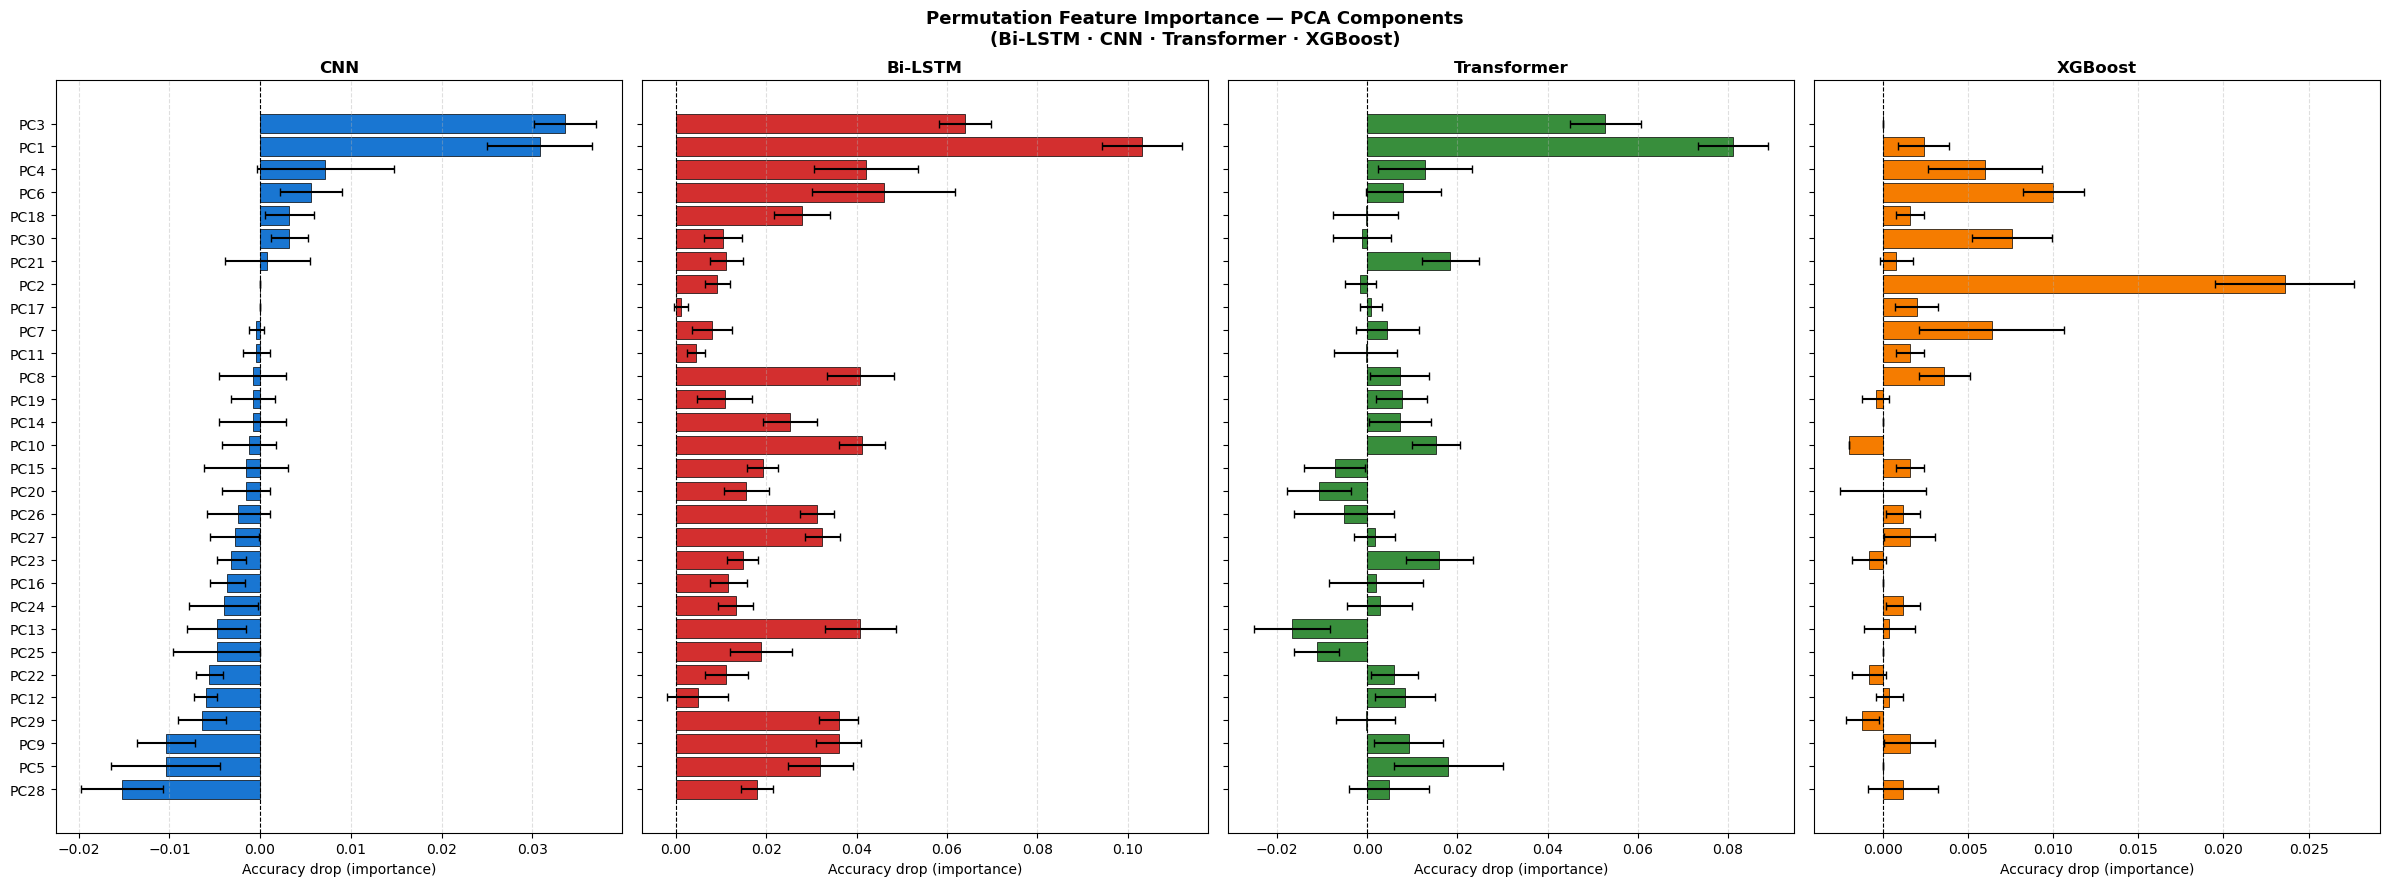

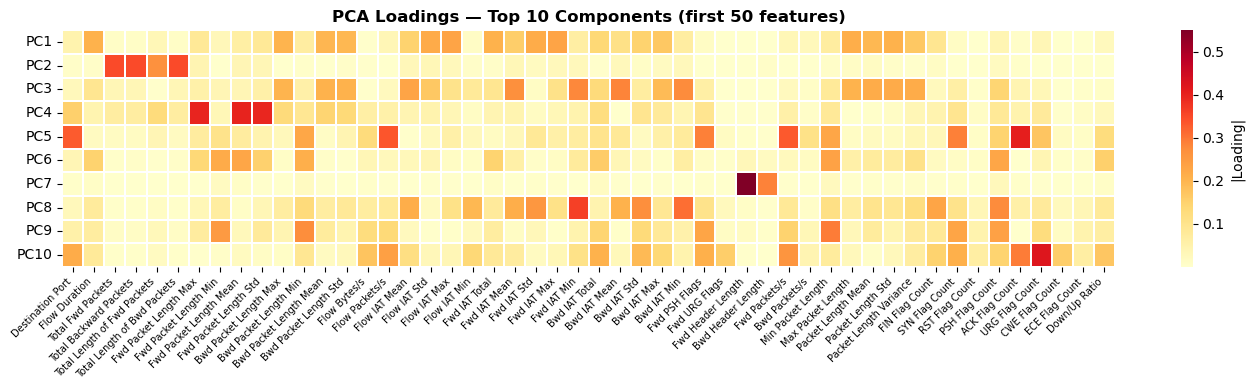

In [21]:
# ── IMPORTANCE BAR CHARTS — all 4 models ─────────────────────────────────────
n_models = len(perm_results)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 9), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (mname, pi) in zip(axes, perm_results.items()):
    col   = MODEL_COLORS.get(mname, "#607D8B")
    order = np.argsort(pi["mean"])
    ax.barh([perm_labels[i] for i in order], pi["mean"][order],
            xerr=pi["std"][order], color=col,
            edgecolor="black", linewidth=0.5, capsize=3)
    ax.set_title(mname, fontweight="bold", fontsize=12)
    ax.set_xlabel("Accuracy drop (importance)")
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.grid(axis="x", ls="--", alpha=0.4)

plt.suptitle("Permutation Feature Importance — PCA Components\n"
             "(Bi-LSTM · CNN · Transformer · XGBoost)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "permutation_importance.png"),
            dpi=130, bbox_inches="tight")
plt.show()

# ── PCA loadings heatmap ───────────────────────────────────────────────────────
top_k    = min(10, N_COMPONENTS)
show_f   = min(50, len(feature_names))
loadings = pd.DataFrame(
    np.abs(pca.components_[:top_k]),
    index   = [f"PC{i+1}" for i in range(top_k)],
    columns = feature_names)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(loadings.iloc[:, :show_f], cmap="YlOrRd", ax=ax,
            linewidths=0.3, cbar_kws={"label": "|Loading|"})
ax.set_title(f"PCA Loadings — Top {top_k} Components (first {show_f} features)",
             fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pca_loadings.png"), dpi=130, bbox_inches="tight")
plt.show()


## Step 15 — Overfitting / Underfitting Analysis

Fit Diagnosis:
────────────────────────────────────────────────────────────
  CNN             Train=94.32%  Val=94.48%  Gap=-0.16%  →  GOOD FIT


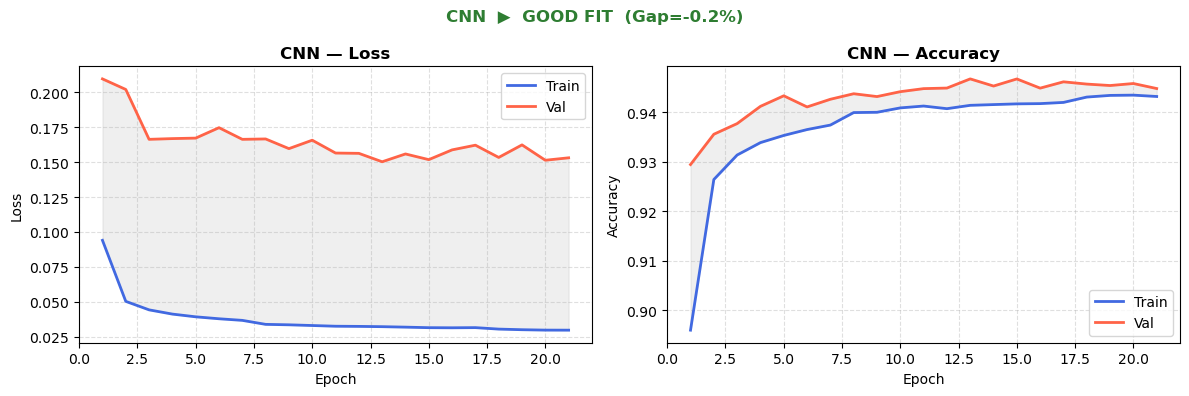

  Bi-LSTM         Train=96.93%  Val=96.80%  Gap=0.13%  →  GOOD FIT


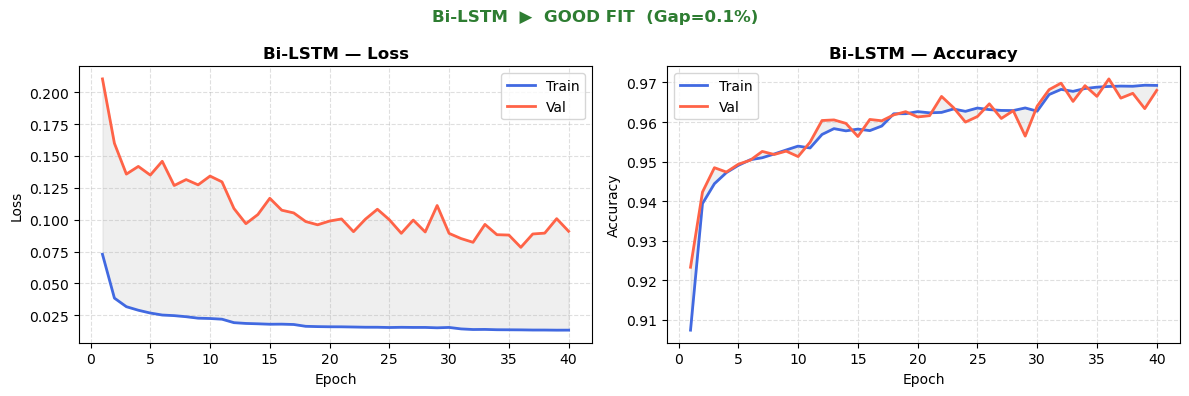

  Transformer     Train=91.39%  Val=92.41%  Gap=-1.01%  →  GOOD FIT


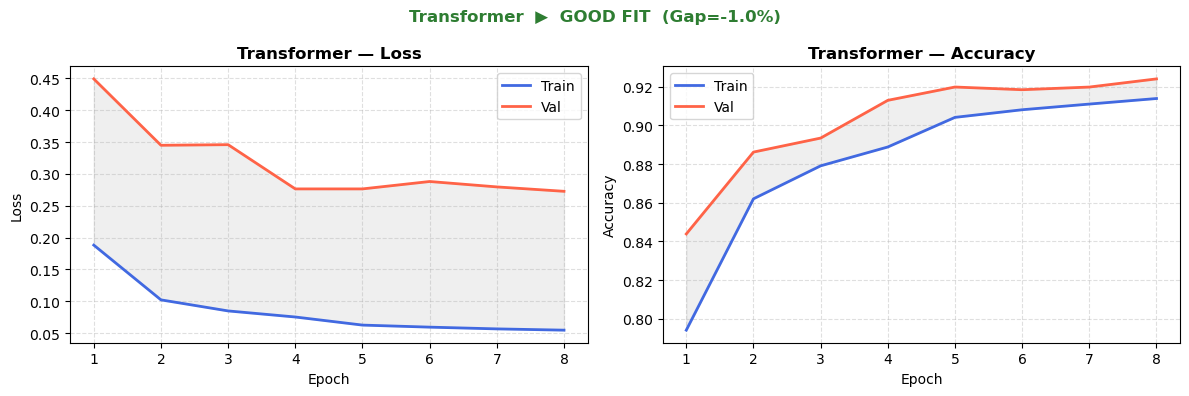

  XGBoost         Train=99.65%  Val=99.60%  Gap=0.05%  →  GOOD FIT


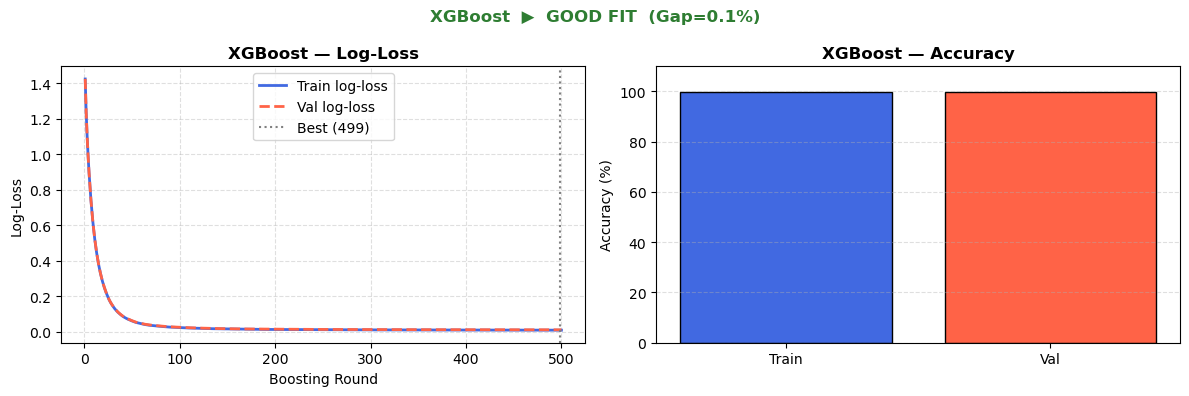

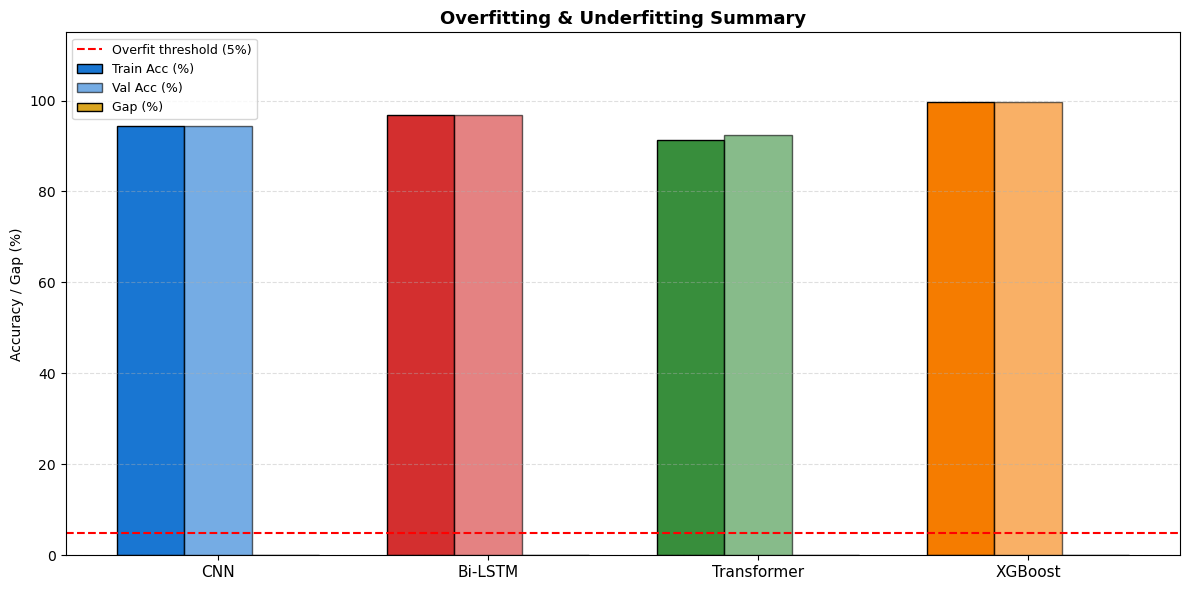

,Model,Diagnosis,Train Acc (%),Val Acc (%),Gap (%)
0,CNN,GOOD FIT,94.32,94.48,-0.16
1,Bi-LSTM,GOOD FIT,96.93,96.80,0.13
2,Transformer,GOOD FIT,91.39,92.41,-1.01
3,XGBoost,GOOD FIT,99.65,99.60,0.05


In [22]:
# ── OVERFITTING / UNDERFITTING ANALYSIS ──────────────────────────────────────
def diagnose_dl(mname, h):
    tr  = h.history["accuracy"]; vl = h.history["val_accuracy"]
    ls  = h.history["val_loss"]
    ft  = tr[-1]; fv = vl[-1]; gap = ft - fv
    trend = float(np.polyfit(range(min(5,len(ls))), ls[-5:], 1)[0])
    if gap > OVERFIT_GAP and trend > 0:   diag, col = "OVERFITTING",  "#C62828"
    elif ft < UNDERFIT_CEIL and fv < UNDERFIT_CEIL: diag, col = "UNDERFITTING","#EF6C00"
    else:                                  diag, col = "GOOD FIT",     "#2E7D32"
    print(f"  {mname:<14}  Train={ft*100:.2f}%  Val={fv*100:.2f}%  "
          f"Gap={gap*100:.2f}%  →  {diag}")
    ep = range(1, len(tr)+1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    for ax, tv, vv, lb in [(a1, h.history["loss"], ls, "Loss"),
                            (a2, tr, vl, "Accuracy")]:
        ax.plot(ep, tv, label="Train", color="royalblue", lw=2)
        ax.plot(ep, vv, label="Val",   color="tomato",    lw=2)
        ax.fill_between(ep, tv, vv, alpha=0.12, color="gray")
        ax.set_title(f"{mname} — {lb}", fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel(lb)
        ax.legend(); ax.grid(True, ls="--", alpha=0.4)
    fig.suptitle(f"{mname}  ▶  {diag}  (Gap={gap*100:.1f}%)",
                 fontsize=12, fontweight="bold", color=col)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"fit_{mname.replace(' ','_')}.png"),
                dpi=130, bbox_inches="tight")
    plt.show()
    return {"diagnosis": diag, "train": ft, "val": fv, "gap": gap}

def diagnose_xgb(mname, model, evals, tr_idx, val_idx):
    tr_loss  = np.array(evals["validation_0"]["mlogloss"])
    val_loss = np.array(evals["validation_1"]["mlogloss"])
    tr_acc   = accuracy_score(y_train[tr_idx], model.predict(X_train_pca[tr_idx]))
    val_acc  = accuracy_score(y_train[val_idx], model.predict(X_train_pca[val_idx]))
    gap      = tr_acc - val_acc
    val_trend = float(np.polyfit(range(min(5,len(val_loss))), val_loss[-5:], 1)[0])
    if gap > OVERFIT_GAP and val_trend > 0:   diag, col = "OVERFITTING",  "#C62828"
    elif tr_acc < UNDERFIT_CEIL and val_acc < UNDERFIT_CEIL: diag, col = "UNDERFITTING","#EF6C00"
    else:                                      diag, col = "GOOD FIT",     "#2E7D32"
    print(f"  {mname:<14}  Train={tr_acc*100:.2f}%  Val={val_acc*100:.2f}%  "
          f"Gap={gap*100:.2f}%  →  {diag}")
    rounds = range(1, len(tr_loss)+1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.plot(rounds, tr_loss,  color="royalblue", lw=2, label="Train log-loss")
    a1.plot(rounds, val_loss, color="tomato",    lw=2, label="Val log-loss", ls="--")
    a1.axvline(model.best_iteration, color="gray", ls=":", label=f"Best ({model.best_iteration})")
    a1.set_title(f"{mname} — Log-Loss", fontweight="bold")
    a1.set_xlabel("Boosting Round"); a1.set_ylabel("Log-Loss")
    a1.legend(); a1.grid(True, ls="--", alpha=0.4)
    a2.bar(["Train","Val"], [tr_acc*100, val_acc*100],
           color=["royalblue","tomato"], edgecolor="black")
    a2.set_ylim(0, 110); a2.set_ylabel("Accuracy (%)")
    a2.set_title(f"{mname} — Accuracy", fontweight="bold")
    a2.grid(axis="y", ls="--", alpha=0.4)
    fig.suptitle(f"{mname}  ▶  {diag}  (Gap={gap*100:.1f}%)",
                 fontsize=12, fontweight="bold", color=col)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"fit_XGBoost.png"),
                dpi=130, bbox_inches="tight")
    plt.show()
    return {"diagnosis": diag, "train": tr_acc, "val": val_acc, "gap": gap}

print("Fit Diagnosis:"); print("─" * 60)
for mn, h in histories.items():
    if h is None:
        fit_diagnoses[mn] = diagnose_xgb(mn, trained_models[mn],
                                          xgb_evals_result,
                                          xgb_tr_idx, xgb_val_idx)
    else:
        fit_diagnoses[mn] = diagnose_dl(mn, h)

# ── Summary bar chart ─────────────────────────────────────────────────────────
models_l = list(fit_diagnoses.keys())
x = np.arange(len(models_l)); w = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x-w, [fit_diagnoses[m]["train"]*100 for m in models_l], w,
       label="Train Acc (%)", color=[MODEL_COLORS.get(m,"#607D8B") for m in models_l],
       edgecolor="black")
ax.bar(x,   [fit_diagnoses[m]["val"]*100   for m in models_l], w,
       label="Val Acc (%)",
       color=[MODEL_COLORS.get(m,"#607D8B") for m in models_l],
       edgecolor="black", alpha=0.6)
ax.bar(x+w, [fit_diagnoses[m]["gap"]*100   for m in models_l], w,
       label="Gap (%)", color="goldenrod", edgecolor="black")
ax.axhline(OVERFIT_GAP*100, color="red", ls="--", lw=1.5,
           label=f"Overfit threshold ({OVERFIT_GAP*100:.0f}%)")
ax.set_xticks(x); ax.set_xticklabels(models_l, fontsize=11)
ax.set_ylabel("Accuracy / Gap (%)"); ax.set_ylim(0, 115)
ax.set_title("Overfitting & Underfitting Summary", fontweight="bold", fontsize=13)
ax.legend(fontsize=9); ax.grid(axis="y", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fit_summary.png"), dpi=130, bbox_inches="tight")
plt.show()
fit_df = pd.DataFrame([
    {"Model": m, "Diagnosis": d["diagnosis"],
     "Train Acc (%)": round(d["train"]*100,2),
     "Val Acc (%)":   round(d["val"]*100,  2),
     "Gap (%)":       round(d["gap"]*100,  2)}
    for m, d in fit_diagnoses.items()])
fit_df.to_csv(os.path.join(OUTPUT_DIR, "fit_diagnosis.csv"), index=False)
display(fit_df)


## Step 16 — TOPSIS Model Comparison Algorithm
TOPSIS (Technique for Order of Preference by Similarity to Ideal Solution) is a published  
MCDM method suitable for IEEE research papers. It ranks models by their weighted Euclidean  
distance from the ideal-best and ideal-worst solutions across 10 evaluation criteria.

  TOPSIS MODEL RANKING — CICIDS2017
      Model  d+ (dist ideal)  d- (dist worst)  TOPSIS Score (C)  Rank
    XGBoost         0.002122         0.078864          0.973793     1
    Bi-LSTM         0.022882         0.067988          0.748189     2
        CNN         0.021838         0.058994          0.729840     3
Transformer         0.076996         0.017101          0.181740     4

  Score closer to 1.0 = closer to ideal solution
  BEST MODEL (TOPSIS) : XGBoost


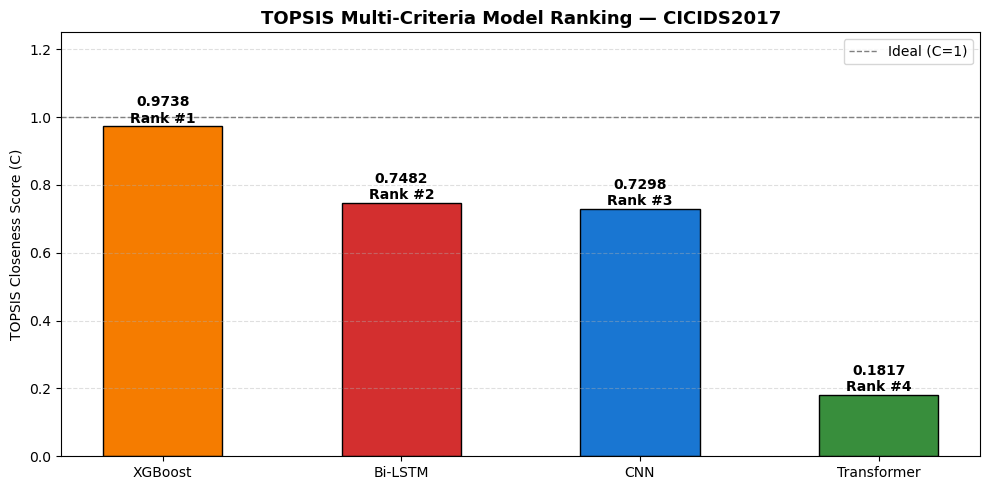

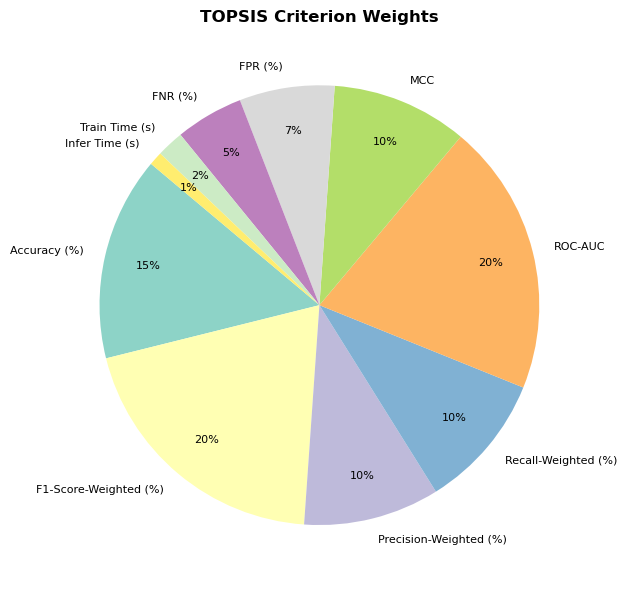

,Model,d+ (dist ideal),d- (dist worst),TOPSIS Score (C),Rank
0,XGBoost,0.002122,0.078864,0.973793,1
1,Bi-LSTM,0.022882,0.067988,0.748189,2
2,CNN,0.021838,0.058994,0.729840,3
3,Transformer,0.076996,0.017101,0.181740,4


In [23]:
# ── TOPSIS MODEL COMPARISON ALGORITHM ────────────────────────────────────────
def topsis(results_df, weights_dict, directions_dict):
    models   = results_df["Model"].tolist()
    criteria = list(weights_dict.keys())
    weights  = np.array([weights_dict[c] for c in criteria])
    dirn     = [directions_dict[c] for c in criteria]
    D        = results_df[criteria].values.astype(float)
    norms    = np.sqrt((D**2).sum(axis=0)); norms[norms==0] = 1
    R        = D / norms
    V        = R * weights
    A_pos    = np.where(np.array(dirn)=="max", V.max(axis=0), V.min(axis=0))
    A_neg    = np.where(np.array(dirn)=="max", V.min(axis=0), V.max(axis=0))
    d_pos    = np.sqrt(((V - A_pos)**2).sum(axis=1))
    d_neg    = np.sqrt(((V - A_neg)**2).sum(axis=1))
    C        = d_neg / (d_pos + d_neg + 1e-12)
    ranks    = (-C).argsort().argsort() + 1
    return pd.DataFrame({
        "Model"           : models,
        "d+ (dist ideal)" : np.round(d_pos, 6),
        "d- (dist worst)" : np.round(d_neg, 6),
        "TOPSIS Score (C)": np.round(C,     6),
        "Rank"            : ranks,
    }).sort_values("Rank").reset_index(drop=True)

# Rename ROC-AUC column to match TOPSIS_WEIGHTS key
results_df_t = pd.DataFrame(all_results).copy()
if "ROC-AUC (Macro-OvR)" in results_df_t.columns:
    results_df_t.rename(columns={"ROC-AUC (Macro-OvR)": "ROC-AUC"}, inplace=True)

topsis_result = topsis(results_df_t, TOPSIS_WEIGHTS, TOPSIS_DIRECTIONS)

print("=" * 65)
print("  TOPSIS MODEL RANKING — CICIDS2017")
print("=" * 65)
print(topsis_result.to_string(index=False))
print("\n  Score closer to 1.0 = closer to ideal solution")
print(f"  BEST MODEL (TOPSIS) : {topsis_result.loc[0, 'Model']}")
topsis_result.to_csv(os.path.join(OUTPUT_DIR, "topsis_ranking.csv"), index=False)

# ── TOPSIS score bar chart ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bar_c = [MODEL_COLORS.get(m, "#607D8B") for m in topsis_result["Model"]]
bars  = ax.bar(topsis_result["Model"], topsis_result["TOPSIS Score (C)"],
               color=bar_c, edgecolor="black", width=0.5)
for b, v, r in zip(bars, topsis_result["TOPSIS Score (C)"], topsis_result["Rank"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f"{v:.4f}\nRank #{r}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.25); ax.set_ylabel("TOPSIS Closeness Score (C)")
ax.set_title("TOPSIS Multi-Criteria Model Ranking — CICIDS2017",
             fontsize=13, fontweight="bold")
ax.axhline(1.0, color="gray", ls="--", lw=1, label="Ideal (C=1)")
ax.legend(); ax.grid(axis="y", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "topsis_ranking.png"), dpi=130, bbox_inches="tight")
plt.show()

# ── Weights pie chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    list(TOPSIS_WEIGHTS.values()),
    labels=list(TOPSIS_WEIGHTS.keys()),
    autopct="%1.0f%%", startangle=140,
    colors=plt.cm.Set3(np.linspace(0, 1, len(TOPSIS_WEIGHTS))),
    pctdistance=0.8)
for t in texts:    t.set_fontsize(8)
for a in autotexts: a.set_fontsize(8)
ax.set_title("TOPSIS Criterion Weights", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "topsis_weights.png"), dpi=130, bbox_inches="tight")
plt.show()
display(topsis_result)


## Step 17 — Final Comparison Table & Plots

Complete metrics table:


Model,CNN,Bi-LSTM,Transformer,XGBoost
Accuracy (%),94.791900,97.126900,84.507100,99.615400
Precision-Weighted (%),96.340400,98.172500,91.044400,99.675600
Recall-Weighted (%),94.791900,97.126900,84.507100,99.615400
F1-Score-Weighted (%),95.232600,97.499300,86.559900,99.634700
Precision-Macro (%),48.991100,61.316100,27.610700,80.658700
Recall-Macro (%),75.152700,86.281600,58.402900,84.096400
F1-Score-Macro (%),56.960700,66.605200,33.534300,80.479300
FPR (%),0.379100,0.202600,1.449300,0.030600
FNR (%),24.847300,13.718400,41.597100,15.903600
ROC-AUC,0.998246,0.999258,0.974506,0.994564


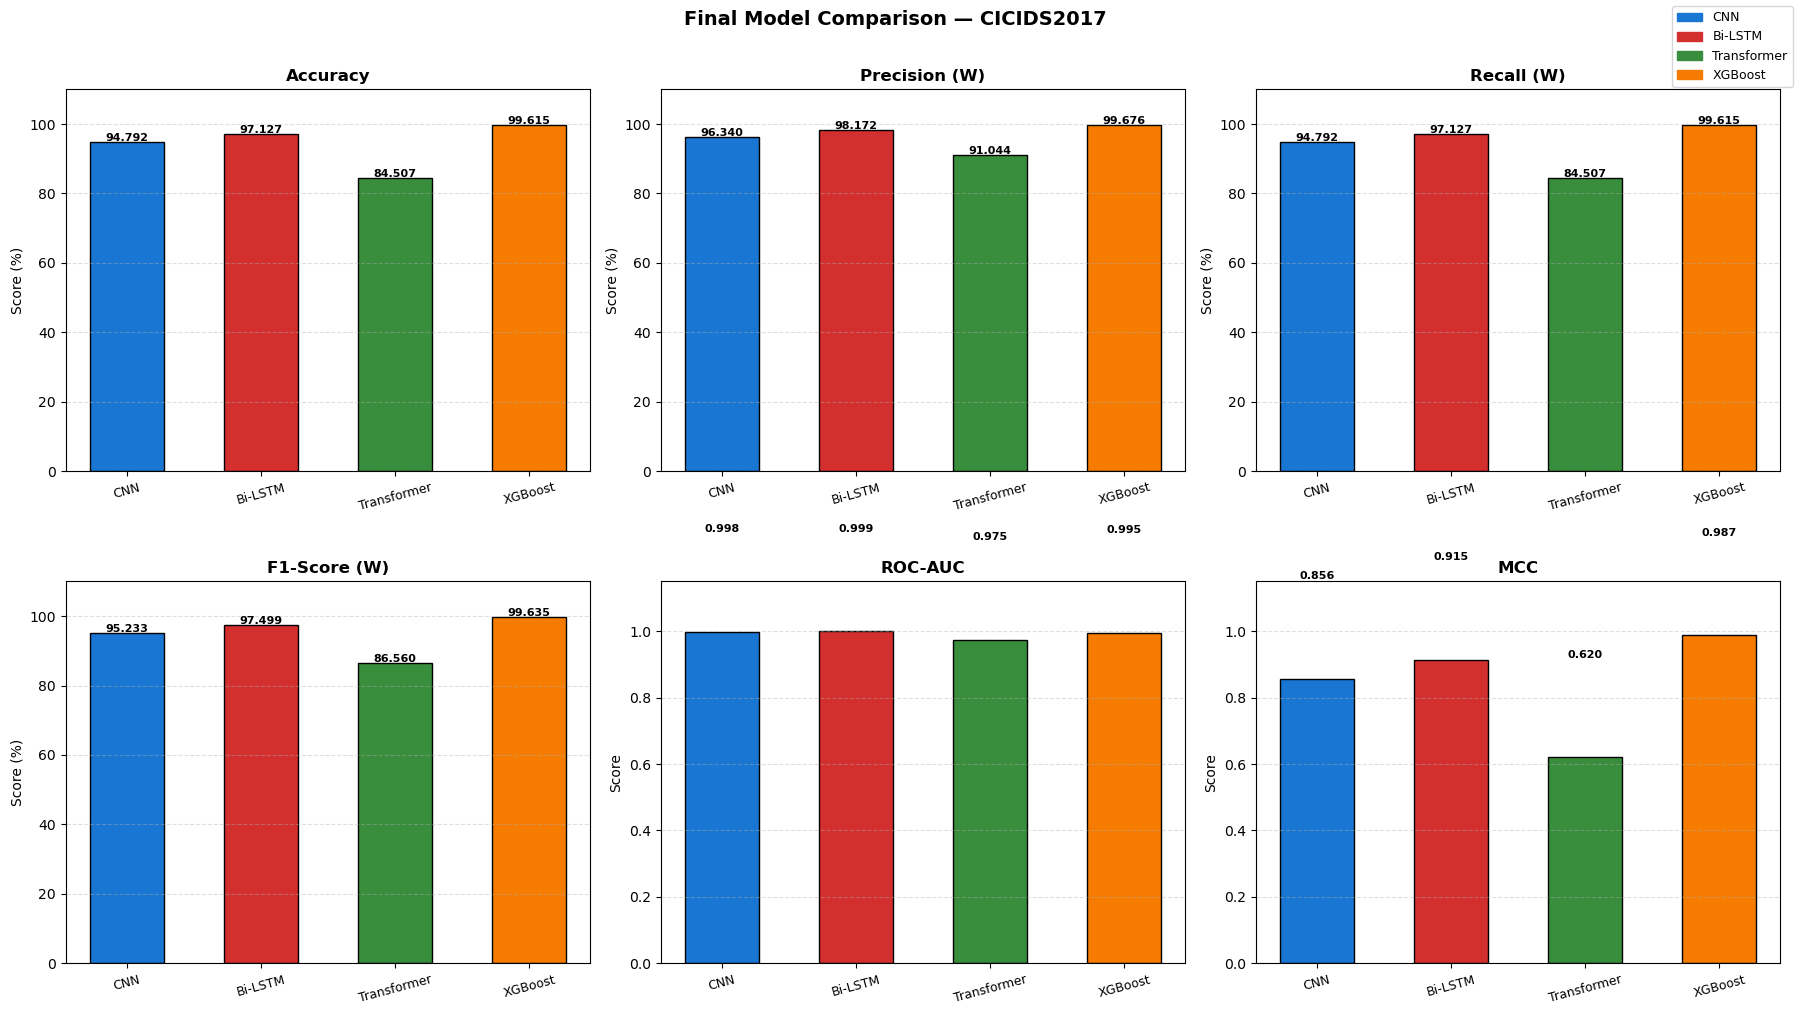

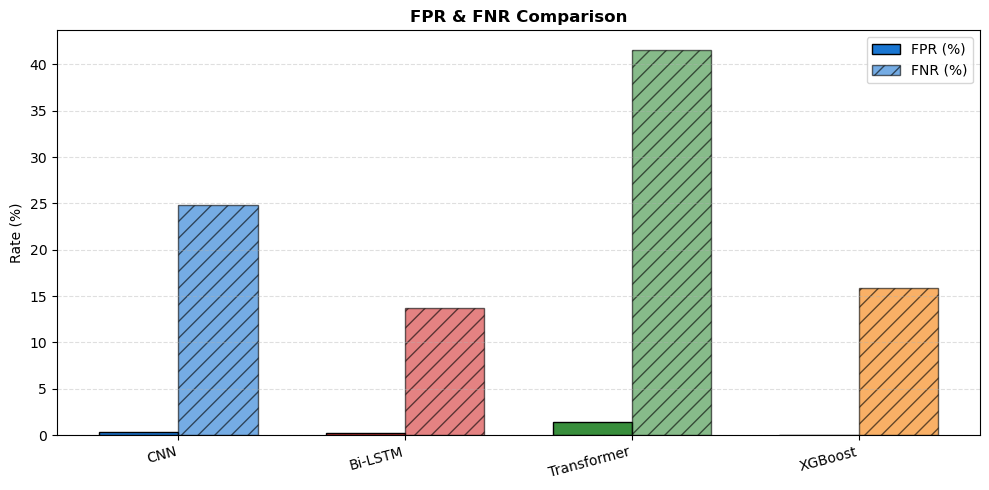

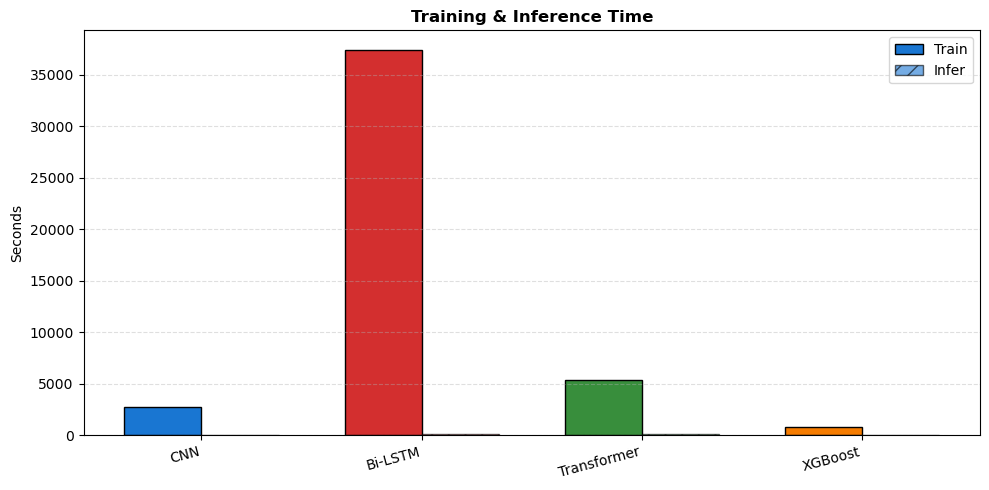

In [24]:
# ── FINAL RESULTS TABLE + COMPARISON PLOTS ────────────────────────────────────
results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(OUTPUT_DIR, "final_results.csv"), index=False)

print("Complete metrics table:")
display(results_df.set_index("Model").T)

plot_metric_bars(results_df, OUTPUT_DIR)
plot_fpr_fnr(results_df,     OUTPUT_DIR)
plot_time(results_df,        OUTPUT_DIR)


## Step 18 — Best Model Declaration & Save

In [25]:
# ── BEST MODEL & SAVE ─────────────────────────────────────────────────────────
results_df  = pd.DataFrame(all_results)
best_topsis = topsis_result.loc[0, "Model"]
bi          = results_df["F1-Score-Weighted (%)"].idxmax()
best_f1     = results_df.loc[bi, "Model"]

print("=" * 68)
print("  FINAL SUMMARY — CICIDS2017  (Bi-LSTM | CNN | Transformer | XGBoost)")
print("=" * 68)
print(f"  Repeated Holdout winner  : {best_rh_model}")
print(f"  TOPSIS ranking winner    : {best_topsis}")
print(f"  F1-Weighted winner       : {best_f1}")
print()
header = (f"  {'Model':<14}  {'Acc':>8}  {'F1-W':>8}  "
          f"{'AUC':>7}  {'MCC':>7}  {'TOPSIS':>8}  Fit")
print(header)
print("  " + "─" * (len(header) - 2))
for _, row in results_df.iterrows():
    m = row["Model"]
    r = topsis_result.loc[topsis_result["Model"] == m, "Rank"].values[0]
    print(f"  {m:<14}  "
          f"{row['Accuracy (%)']:>7.3f}%  "
          f"{row['F1-Score-Weighted (%)']:>7.3f}%  "
          f"{row['ROC-AUC']:>7.4f}  "
          f"{row['MCC']:>7.4f}  "
          f"Rank #{r:<2}  "
          f"{fit_diagnoses[m]['diagnosis']}")
print("=" * 68)

# Save DL models (.keras)
for mname, mdl in trained_models.items():
    if isinstance(mdl, XGBClassifier):
        continue  # saved separately below
    safe = mname.replace("-","_").replace(" ","_")
    path = os.path.join(OUTPUT_DIR, f"{safe}.keras")
    mdl.save(path)
    print(f"  Saved DL  : {path}")

# Save XGBoost model (.json) — XGBoost native format, portable across versions
xgb_path = os.path.join(OUTPUT_DIR, "XGBoost.json")
trained_models["XGBoost"].save_model(xgb_path)
print(f"  Saved XGB : {xgb_path}")

results_df.to_csv(os.path.join(OUTPUT_DIR, "final_results.csv"), index=False)
print(f"\n✓  All outputs saved to: {OUTPUT_DIR}")
ram()


  FINAL SUMMARY — CICIDS2017  (Bi-LSTM | CNN | Transformer | XGBoost)
  Repeated Holdout winner  : XGBoost
  TOPSIS ranking winner    : XGBoost
  F1-Weighted winner       : XGBoost

  Model                Acc      F1-W      AUC      MCC    TOPSIS  Fit
  ───────────────────────────────────────────────────────────────────
  CNN              94.792%   95.233%   0.9982   0.8563  Rank #3   GOOD FIT
  Bi-LSTM          97.127%   97.499%   0.9993   0.9146  Rank #2   GOOD FIT
  Transformer      84.507%   86.560%   0.9745   0.6203  Rank #4   GOOD FIT
  XGBoost          99.615%   99.635%   0.9946   0.9874  Rank #1   GOOD FIT
  Saved DL  : C:\Users\saina\Downloads\IDS_Thesis\Final_Results\CNN.keras
  Saved DL  : C:\Users\saina\Downloads\IDS_Thesis\Final_Results\Bi_LSTM.keras
  Saved DL  : C:\Users\saina\Downloads\IDS_Thesis\Final_Results\Transformer.keras
  Saved XGB : C:\Users\saina\Downloads\IDS_Thesis\Final_Results\XGBoost.json

✓  All outputs saved to: C:\Users\saina\Downloads\IDS_Thesis\Final